# Non-pregnant anemia prevalence and DALYs averted by fortification

We take a "multiplication model" approach here, shifting continuous hemoglobin (as estimated
by GBD) and seeing what impact that has on anemia and therefore YLDs.

It's important to note that we directly use hemoglobin estimates, which are the first step
of the GBD anemia estimation pipeline. The risks and causes that are related to anemia are
all calculated downstream from this.

In [1]:
import vivarium.gbd_mapping as gbd_mapping
import pathlib
import pandas as pd, numpy as np
import vivarium_inputs
from db_queries import get_ids
import warnings
from lsff_utils import config_utils
from lsff_utils import gbd_data
from lsff_utils.hemoglobin_distribution import (
    hemoglobin_pdf_from_mean_sd,
    hemoglobin_cdf_from_mean_sd,
)

from vivarium_inputs.validation.raw import DataDoesNotExistError, DataAbnormalError
from tqdm.notebook import tqdm

In [2]:
pd.set_option("display.max_columns", 30)

In [3]:
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [4]:
location = "india"
vehicle = "rice"

In [5]:
# Parameters
location = "india"
vehicle = "rice"


In [6]:
intervention_scenarios = config_utils.get_intervention_scenarios(location, vehicle)
intervention_scenarios

['intervention']

## Setup and scenarios

In [7]:
# GBD estimation year every pull below uses. Owned by gbd_data; shown here
# so a run's output records which year it was built against.
gbd_data.most_recent_year()

2023

In [8]:
# Save the set of draws used in gbd_data when pulling modelable entities
# so we can make sure to use the same draws for the sequela prevalences
# below
DRAWS = gbd_data.DRAWS
len(DRAWS)

250

In [9]:
effective_coverage_baseline = pd.read_csv(
    f"../0100_data_prep/results/iron/{vehicle}/baseline_fortification/effective_coverage/{location}.csv"
)
assert (effective_coverage_baseline.vehicle_name == vehicle).all()
effective_coverage_baseline = effective_coverage_baseline.drop(columns=["vehicle_name"])
effective_coverage_baseline

,wealth_quintile,sex,age_start,age_end,value
0,1,Female,0,5,0.271771
1,1,Female,5,15,0.354580
2,1,Female,15,30,0.318263
3,1,Female,30,50,0.339757
4,1,Female,50,125,0.351941
5,1,Male,0,5,0.270326
6,1,Male,5,15,0.359366
7,1,Male,15,30,0.333086
8,1,Male,30,50,0.331810
9,1,Male,50,125,0.349362


In [10]:
def expand(df):
    for col in sorted(list(set(df.columns) - {"value"})):
        if df[col].isnull().any():
            df = pd.concat(
                [
                    df[df[col].notnull()],
                    *[
                        df[df[col].isnull()].assign(**{col: value})
                        for value in df[df[col].notnull()][col].unique()
                    ],
                ]
            )

    return df

In [11]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_baseline.columns:
        effective_coverage_baseline[col] = fill_value
    else:
        effective_coverage_baseline[col] = effective_coverage_baseline[col].fillna(
            fill_value
        )

In [12]:
effective_coverage_baseline = expand(effective_coverage_baseline)
effective_coverage_baseline

,wealth_quintile,sex,age_start,age_end,value
0,1,Female,0,5,0.271771
1,1,Female,5,15,0.354580
2,1,Female,15,30,0.318263
3,1,Female,30,50,0.339757
4,1,Female,50,125,0.351941
5,1,Male,0,5,0.270326
6,1,Male,5,15,0.359366
7,1,Male,15,30,0.333086
8,1,Male,30,50,0.331810
9,1,Male,50,125,0.349362


In [13]:
effective_coverage_intervention = pd.concat(
    [
        pd.read_csv(
            f"../0100_data_prep/results/iron/{vehicle}/{intervention_scenario}/intervention_fortification/effective_coverage/{location}.csv"
        ).assign(scenario=intervention_scenario)
        for intervention_scenario in intervention_scenarios
    ]
)
assert (effective_coverage_intervention.vehicle_name == vehicle).all()
effective_coverage_intervention = effective_coverage_intervention.drop(
    columns=["vehicle_name"]
)
effective_coverage_intervention

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0,5,1,0.488053,intervention
1,Female,0,5,2,0.486030,intervention
2,Female,0,5,3,0.485452,intervention
3,Female,0,5,4,0.491300,intervention
4,Female,0,5,5,0.435223,intervention
5,Female,5,15,1,0.576075,intervention
6,Female,5,15,2,0.590182,intervention
7,Female,5,15,3,0.593898,intervention
8,Female,5,15,4,0.579074,intervention
9,Female,5,15,5,0.509649,intervention


In [14]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_coverage_intervention.columns:
        effective_coverage_intervention[col] = fill_value
    else:
        effective_coverage_intervention[col] = effective_coverage_intervention[
            col
        ].fillna(fill_value)

In [15]:
effective_coverage_intervention = expand(effective_coverage_intervention)
effective_coverage_intervention

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0,5,1,0.488053,intervention
1,Female,0,5,2,0.486030,intervention
2,Female,0,5,3,0.485452,intervention
3,Female,0,5,4,0.491300,intervention
4,Female,0,5,5,0.435223,intervention
5,Female,5,15,1,0.576075,intervention
6,Female,5,15,2,0.590182,intervention
7,Female,5,15,3,0.593898,intervention
8,Female,5,15,4,0.579074,intervention
9,Female,5,15,5,0.509649,intervention


In [16]:
population = pd.read_csv(
    f"../0100_data_prep/results/population/stratified/{location}.csv"
)

In [17]:
non_pregnant_pop = population.pipe(lambda df: df[df.pregnant == "not_pregnant"]).drop(
    columns="pregnant"
)
non_pregnant_pop = non_pregnant_pop.set_index(
    [c for c in non_pregnant_pop.columns if c != "value"]
).value
non_pregnant_pop

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  48678.711021
                               2                  42723.422230
                               3                  37932.716572
                               4                  35728.167677
                               5                  28631.476092
                                                      ...     
Male    95.0       125.000000  1                  18328.880607
                               2                  19140.234171
                               3                  19770.250303
                               4                  20851.307187
                               5                  25711.282133
Name: value, Length: 250, dtype: float64

In [18]:
example_sex = "Female"
example_age_start = 25
example_age_end = 30
example_wealth_quintile = 1
example_tuple = (
    example_sex,
    example_age_start,
    example_age_end,
    example_wealth_quintile,
)

In [19]:
population.set_index(["sex", "age_start", "age_end"]).loc[
    (example_sex, example_age_start, example_age_end)
].value.sum()

61598644.000825964

In [20]:
non_pregnant_pop.loc[(example_sex, example_age_start, example_age_end)][1]

9827652.103046143

In [21]:
non_pregnant_pop.loc[(example_sex, example_age_start, example_age_end)].sum()

55257013.14629988

In [22]:
population_age_groups = (
    non_pregnant_pop.reset_index()[["age_start", "age_end"]]
    .drop_duplicates()
    .sort_values("age_start")
)
population_age_groups

,age_start,age_end
0,0.000000,0.019178
5,0.019178,0.076712
10,0.076712,0.500000
15,0.500000,1.000000
20,1.000000,2.000000
25,2.000000,5.000000
30,5.000000,10.000000
35,10.000000,15.000000
40,15.000000,20.000000
45,20.000000,25.000000


In [23]:
def map_to_population_age_groups(df):
    result = (
        population_age_groups.merge(df, how="cross", suffixes=("", "_orig"))
        .pipe(
            lambda df: df[
                (df.age_end <= df.age_end_orig) & (df.age_start >= df.age_start_orig)
            ]
        )
        .drop(columns=["age_start_orig", "age_end_orig"])
    )
    return result

In [24]:
effective_coverage_baseline = (
    map_to_population_age_groups(effective_coverage_baseline)
    .set_index([c for c in effective_coverage_baseline.columns if c != "value"])
    .value
)
effective_coverage_intervention = (
    map_to_population_age_groups(effective_coverage_intervention)
    .set_index([c for c in effective_coverage_intervention.columns if c != "value"])
    .value
)

In [25]:
if "sex" not in effective_coverage_baseline.index.names:
    # Assume does not vary
    effective_coverage_baseline = pd.concat(
        [
            effective_coverage_baseline.reset_index()
            .assign(sex="Female")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
            effective_coverage_baseline.reset_index()
            .assign(sex="Male")
            .set_index(["wealth_quintile", "sex", "age_start", "age_end"])
            .value,
        ]
    )

In [26]:
effective_coverage_baseline = (
    effective_coverage_baseline.reset_index()
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)

In [27]:
if "sex" not in effective_coverage_intervention.index.names:
    # Assume does not vary
    effective_coverage_intervention = pd.concat(
        [
            effective_coverage_intervention.to_frame()
            .assign(sex="Female")
            .set_index("sex", append=True)
            .reorder_levels(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
            effective_coverage_intervention.to_frame()
            .assign(sex="Male")
            .set_index("sex", append=True)
            .reorder_levels(["sex", "age_start", "age_end", "wealth_quintile"])
            .value,
        ]
    )

In [28]:
effective_coverage_intervention = effective_coverage_intervention.reorder_levels(
    ["sex", "age_start", "age_end", "wealth_quintile", "scenario"]
)

In [29]:
effective_coverage_baseline.loc[example_tuple]

0.3182633258449152

In [30]:
effective_coverage_intervention.loc[example_tuple]

scenario
intervention    0.535365
Name: value, dtype: float64

## Pull GBD hemoglobin distribution statistics

In [31]:
me_ids = {
    "hemoglobin_mean": 10487,
    "hemoglobin_sd": 10488,
}

# Verify the MEIDs against get_ids
meids_df = get_ids('modelable_entity')
assert (
    meids_df.loc[
        meids_df['modelable_entity_id'] == me_ids["hemoglobin_mean"],
        'modelable_entity_name'].squeeze()
        == 'Mean Hemoglobin (g/L, elevation adjusted) - Custom')
assert (
    meids_df.loc[
        meids_df['modelable_entity_id'] == me_ids["hemoglobin_sd"],
        'modelable_entity_name'].squeeze()
        == 'Standard Deviation of Hemoglobin (g/L, survey elevation adjusted)')
# Model versions pinned explicitly. Passing version_id skips vivarium_gbd_access's
# version resolution, which goes through rotisserie -- and rotisserie has no
# rotation context for these custom MEs (RotisserieNotFoundError). Recovered from a
# warm cache, so these are whatever was current then; revisit when the round moves.
me_version_ids = {
    "hemoglobin_mean": 882457,
    "hemoglobin_sd": 882401,
}

In [32]:
gbd_hgb_mean = gbd_data.pull_modelable_entity_draws(
    me_ids["hemoglobin_mean"], location, version_id=me_version_ids["hemoglobin_mean"]
)
gbd_hgb_mean

/ihme/homes/ndbs/miniconda3/envs/vivarium_gates_lsff_2026_artifact/lib/python3.11/site-packages/get_draws/base/utils.py:159: RemovedIn20Warning: Deprecated API features detected! These feature(s) are not compatible with SQLAlchemy 2.0. To prevent incompatible upgrades prior to updating applications, ensure requirements files are pinned to "sqlalchemy<2.0". Set environment variable SQLALCHEMY_WARN_20=1 to show all deprecation warnings.  Set environment variable SQLALCHEMY_SILENCE_UBER_WARNING=1 to silence this message. (Background on SQLAlchemy 2.0 at: https://sqlalche.me/e/b8d9)
  session.execute(


draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    160.944235  153.232284  142.907847  158.055053   
       0.019178  0.076712    142.577341  136.312467  126.959162  140.471135   
       0.076712  0.500000    107.955345  110.005276  105.242791  110.217049   
       0.500000  1.000000    106.510807  107.881912  105.114334  106.028959   
       1.000000  2.000000    101.796887  104.851356  101.964949  102.617991   
       2.000000  5.000000    106.937233  109.946831  107.476724  107.513444   
       5.000000  10.000000   112.905874  115.403139  110.738781  113.113996   
       10.000000 15.000000   126.686870  121.203707  113.219563  124.681437   
       15.000000 20.000000   116.840716  119.727532  116.760983  117.864384   
       20.000000 25.000000   117.492951  120.281645  117.069287  118.622364   
       25.000000 30.000000   117.734132  120.679397  117.367620  118.665717   
       30.000000 35.000000   117.276549  120.535560  117.772335  116.366517   
       35.000000 40.000000   116.858995  120.260163  117.479123  116.085515   
       40.000000 45.000000   116.625857  120.042474  117.230268  115.861784   
       45.000000 50.000000   117.733921  121.065653  117.733751  118.742825   
       50.000000 55.000000   126.386870  122.881776  115.034725  124.838988   
       55.000000 60.000000   129.130176  123.407326  115.083517  126.897075   
       60.000000 65.000000   129.647779  123.842842  115.485121  127.375295   
       65.000000 70.000000   128.913357  123.103054  114.798051  126.637185   
       70.000000 75.000000   129.968812  124.066948  115.686631  127.641170   
       75.000000 80.000000   128.543105  122.679927  114.396083  126.220155   
       80.000000 85.000000   128.471070  122.395737  114.151753  126.231590   
       85.000000 90.000000   128.849889  122.716120  114.455923  126.570182   
       90.000000 95.000000   127.847889  121.713343  113.527067  125.546196   
       95.000000 125.000000  127.721014  121.565312  113.392587  125.399415   
Male   0.000000  0.019178    168.388898  160.623414  150.233024  165.472679   
       0.019178  0.076712    142.848128  137.413655  128.199038  141.298817   
       0.076712  0.500000    109.516626  109.252028  101.540999  111.345372   
       0.500000  1.000000    107.933114  105.073550  101.548408  103.988210   
       1.000000  2.000000    101.608377  104.806701  100.501699  101.950918   
       2.000000  5.000000    107.475916  111.314621  106.886984  108.125595   
       5.000000  10.000000   115.332009  116.512478  110.981347  115.464475   
       10.000000 15.000000   133.959295  127.755623  119.501110  131.619664   
       15.000000 20.000000   136.905404  143.662331  138.762110  138.854059   
       20.000000 25.000000   142.175165  149.146591  144.205778  144.088223   
       25.000000 30.000000   142.414626  149.224634  144.269825  144.262948   
       30.000000 35.000000   141.952636  148.672834  143.608343  143.786442   
       35.000000 40.000000   141.047215  147.585588  142.579071  142.709370   
       40.000000 45.000000   139.975340  146.287675  141.175349  141.618218   
       45.000000 50.000000   139.096898  145.413080  140.422875  140.692584   
       50.000000 55.000000   137.853820  143.840949  138.878595  139.196192   
       55.000000 60.000000   147.886348  141.130777  132.006804  145.377696   
       60.000000 65.000000   148.173343  141.335509  132.210488  145.602637   
       65.000000 70.000000   146.501749  139.711018  130.695471  143.935985   
       70.000000 75.000000   143.502855  136.839094  128.009812  140.980313   
       75.000000 80.000000   139.168786  132.700938  124.138487  136.718443   
       80.000000 85.000000   141.155731  134.592969  125.908102  138.668537   
       85.000000 90.000000   139.359982  132.879272  124.304644  136.903409   
       90.000000 95.000000   137.075639  130.700127  122.265721  134.658621   
    

In [33]:
gbd_hgb_mean.loc[("Female", 25, 30)].mean()

117.79590299120615

In [34]:
hemoglobin_mean_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/mean_disparities/{location}.csv"
)
hemoglobin_mean_disparities = (
    map_to_population_age_groups(
        hemoglobin_mean_disparities[
            hemoglobin_mean_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_mean_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  103.655561
                               2                  105.257986
                               3                  105.397530
                               4                  106.765336
                               5                  107.989017
                                                     ...    
Male    95.0       125.000000  1                  115.022635
                               2                  116.108207
                               3                  116.488978
                               4                  117.310740
                               5                  118.402649
Name: value, Length: 250, dtype: float64

In [35]:
wealth_quintile_probabilities = pd.read_csv(
    f"../0100_data_prep/results/wealth_quintile_probabilities/{location}.csv"
)
wealth_quintile_probabilities

,sex,age_start,age_end,pregnant,1,2,3,4,5
0,Female,0.0,5.0,not_pregnant,0.251317,0.220571,0.195838,0.184456,0.147818
1,Female,5.0,15.0,not_pregnant,0.269038,0.219459,0.193766,0.172569,0.145167
2,Female,15.0,30.0,not_pregnant,0.177853,0.202279,0.211418,0.210441,0.198009
3,Female,15.0,30.0,pregnant,0.221117,0.222530,0.215087,0.182296,0.158970
4,Female,30.0,50.0,not_pregnant,0.172597,0.187138,0.199031,0.213495,0.227738
5,Female,30.0,50.0,pregnant,0.316131,0.181401,0.129805,0.169147,0.203517
6,Female,50.0,125.0,not_pregnant,0.188708,0.187540,0.191253,0.199636,0.232863
7,Male,0.0,5.0,not_pregnant,0.242600,0.215610,0.200229,0.183923,0.157639
8,Male,5.0,15.0,not_pregnant,0.261604,0.217675,0.190718,0.176545,0.153458
9,Male,15.0,30.0,not_pregnant,0.169172,0.205794,0.214029,0.208330,0.202675


In [36]:
wealth_quintile_probabilities = map_to_population_age_groups(
    wealth_quintile_probabilities[
        wealth_quintile_probabilities.pregnant == "not_pregnant"
    ].drop(columns=["pregnant"])
).set_index(["sex", "age_start", "age_end"])
wealth_quintile_probabilities.columns.name = "wealth_quintile"
wealth_quintile_probabilities = wealth_quintile_probabilities.stack()
# TODO: Store wealth quintile probabilities without using numbers as columns
wealth_quintile_probabilities = (
    wealth_quintile_probabilities.rename("value")
    .reset_index()
    .assign(wealth_quintile=lambda df: df.wealth_quintile.astype(int))
    .set_index(wealth_quintile_probabilities.index.names)
    .value
)
wealth_quintile_probabilities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.251317
                               2                  0.220571
                               3                  0.195838
                               4                  0.184456
                               5                  0.147818
                                                    ...   
Male    95.0       125.000000  1                  0.176575
                               2                  0.184392
                               3                  0.190461
                               4                  0.200876
                               5                  0.247696
Name: value, Length: 250, dtype: float64

In [37]:
assert np.allclose(
    wealth_quintile_probabilities.groupby(["sex", "age_start", "age_end"]).sum(), 1.0
)

In [38]:
def distribute_by_disparities(df, disparities):
    pre_disparity_groups = (
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print("Before distributing by disparities:")
    display(pre_disparity_groups)

    df = df.mul(disparities, axis=0)

    scale_factor = (
        pre_disparity_groups
        / df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum()
    )
    print(f"Scale factor: {scale_factor}")

    df = df * scale_factor

    assert np.allclose(
        df.mul(wealth_quintile_probabilities, axis=0)
        .groupby([c for c in df.index.names if c != "wealth_quintile"])
        .sum(),
        pre_disparity_groups,
    )

    return df

In [39]:
hgb_mean = distribute_by_disparities(gbd_hgb_mean, hemoglobin_mean_disparities)

Before distributing by disparities:


draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    160.944235  153.232284  142.907847  158.055053   
       0.019178  0.076712    142.577341  136.312467  126.959162  140.471135   
       0.076712  0.500000    107.955345  110.005276  105.242791  110.217049   
       0.500000  1.000000    106.510807  107.881912  105.114334  106.028959   
       1.000000  2.000000    101.796887  104.851356  101.964949  102.617991   
       2.000000  5.000000    106.937233  109.946831  107.476724  107.513444   
       5.000000  10.000000   112.905874  115.403139  110.738781  113.113996   
       10.000000 15.000000   126.686870  121.203707  113.219563  124.681437   
       15.000000 20.000000   116.840716  119.727532  116.760983  117.864384   
       20.000000 25.000000   117.492951  120.281645  117.069287  118.622364   
       25.000000 30.000000   117.734132  120.679397  117.367620  118.665717   
       30.000000 35.000000   117.276549  120.535560  117.772335  116.366517   
       35.000000 40.000000   116.858995  120.260163  117.479123  116.085515   
       40.000000 45.000000   116.625857  120.042474  117.230268  115.861784   
       45.000000 50.000000   117.733921  121.065653  117.733751  118.742825   
       50.000000 55.000000   126.386870  122.881776  115.034725  124.838988   
       55.000000 60.000000   129.130176  123.407326  115.083517  126.897075   
       60.000000 65.000000   129.647779  123.842842  115.485121  127.375295   
       65.000000 70.000000   128.913357  123.103054  114.798051  126.637185   
       70.000000 75.000000   129.968812  124.066948  115.686631  127.641170   
       75.000000 80.000000   128.543105  122.679927  114.396083  126.220155   
       80.000000 85.000000   128.471070  122.395737  114.151753  126.231590   
       85.000000 90.000000   128.849889  122.716120  114.455923  126.570182   
       90.000000 95.000000   127.847889  121.713343  113.527067  125.546196   
       95.000000 125.000000  127.721014  121.565312  113.392587  125.399415   
Male   0.000000  0.019178    168.388898  160.623414  150.233024  165.472679   
       0.019178  0.076712    142.848128  137.413655  128.199038  141.298817   
       0.076712  0.500000    109.516626  109.252028  101.540999  111.345372   
       0.500000  1.000000    107.933114  105.073550  101.548408  103.988210   
       1.000000  2.000000    101.608377  104.806701  100.501699  101.950918   
       2.000000  5.000000    107.475916  111.314621  106.886984  108.125595   
       5.000000  10.000000   115.332009  116.512478  110.981347  115.464475   
       10.000000 15.000000   133.959295  127.755623  119.501110  131.619664   
       15.000000 20.000000   136.905404  143.662331  138.762110  138.854059   
       20.000000 25.000000   142.175165  149.146591  144.205778  144.088223   
       25.000000 30.000000   142.414626  149.224634  144.269825  144.262948   
       30.000000 35.000000   141.952636  148.672834  143.608343  143.786442   
       35.000000 40.000000   141.047215  147.585588  142.579071  142.709370   
       40.000000 45.000000   139.975340  146.287675  141.175349  141.618218   
       45.000000 50.000000   139.096898  145.413080  140.422875  140.692584   
       50.000000 55.000000   137.853820  143.840949  138.878595  139.196192   
       55.000000 60.000000   147.886348  141.130777  132.006804  145.377696   
       60.000000 65.000000   148.173343  141.335509  132.210488  145.602637   
       65.000000 70.000000   146.501749  139.711018  130.695471  143.935985   
       70.000000 75.000000   143.502855  136.839094  128.009812  140.980313   
       75.000000 80.000000   139.168786  132.700938  124.138487  136.718443   
       80.000000 85.000000   141.155731  134.592969  125.908102  138.668537   
       85.000000 90.000000   139.359982  132.879272  124.304644  136.903409   
       90.000000 95.000000   137.075639  130.700127  122.265721  134.658621   
    

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.009473  0.009473  0.009473  0.009473  0.009473   
       0.019178  0.076712    0.009473  0.009473  0.009473  0.009473  0.009473   
       0.076712  0.500000    0.009473  0.009473  0.009473  0.009473  0.009473   
       0.500000  1.000000    0.009473  0.009473  0.009473  0.009473  0.009473   
       1.000000  2.000000    0.009473  0.009473  0.009473  0.009473  0.009473   
       2.000000  5.000000    0.009473  0.009473  0.009473  0.009473  0.009473   
       5.000000  10.000000   0.009011  0.009011  0.009011  0.009011  0.009011   
       10.000000 15.000000   0.009011  0.009011  0.009011  0.009011  0.009011   
       15.000000 20.000000   0.008569  0.008569  0.008569  0.008569  0.008569   
       20.000000 25.000000   0.008569  0.008569  0.008569  0.008569  0.008569   
       25.0000

In [40]:
gbd_hgb_mean.columns.name = "draw"
gbd_hgb_mean = gbd_hgb_mean.stack().rename("mean")

In [41]:
hgb_mean.columns.name = "draw"
hgb_mean = hgb_mean.stack().rename("mean")

In [42]:
gbd_hgb_sd = gbd_data.pull_modelable_entity_draws(
    me_ids["hemoglobin_sd"], location, version_id=me_version_ids["hemoglobin_sd"]
)
gbd_hgb_sd

draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    24.071934  12.292796  25.049782  13.048027   
       0.019178  0.076712    27.051686  16.163402  14.035699  17.906229   
       0.076712  0.500000    19.440669  17.843328  19.456522  17.464026   
       0.500000  1.000000    20.204090  17.990656  19.592082  16.020994   
       1.000000  2.000000    18.370782  20.901309  19.831100  18.536130   
       2.000000  5.000000    18.924135  19.341852  20.361337  17.955356   
       5.000000  10.000000   13.316554  18.567404  14.834947  15.049751   
       10.000000 15.000000   31.597631  22.009883  17.310431  23.814815   
       15.000000 20.000000   20.981715  22.782263  22.921167  20.791513   
       20.000000 25.000000   21.449297  22.624560  22.896163  20.831992   
       25.000000 30.000000   21.587572  22.603431  23.062966  20.623910   
       30.000000 35.000000   22.571316  20.713337  23.386191  17.032223   
       35.000000 40.000000   22.693452  21.616962  23.745185  17.530560   
       40.000000 45.000000   22.873552  22.341272  23.980151  18.022635   
       45.000000 50.000000   22.333406  23.584926  24.291093  21.532235   
       50.000000 55.000000   28.345414  21.114146  16.823839  21.554785   
       55.000000 60.000000   31.111264  21.689044  17.801395  23.416504   
       60.000000 65.000000   31.694122  22.180216  18.114045  23.960465   
       65.000000 70.000000   31.338265  22.047919  17.564089  24.027988   
       70.000000 75.000000   32.367155  22.988167  18.253129  24.969343   
       75.000000 80.000000   30.317680  20.867490  16.730685  22.761837   
       80.000000 85.000000   29.922917  20.161451  16.253263  22.344178   
       85.000000 90.000000   30.252150  20.075122  15.939677  22.091046   
       90.000000 95.000000   29.491772  18.713978  15.526507  20.649068   
       95.000000 125.000000  29.902287  19.318803  15.781480  21.186912   
Male   0.000000  0.019178    13.931687   6.532212   6.768531   5.291191   
       0.019178  0.076712    24.306655  13.532990  12.577452  14.986293   
       0.076712  0.500000    21.013775  20.721135  16.882206  24.369191   
       0.500000  1.000000    23.479565  19.436902  16.951040  18.586482   
       1.000000  2.000000    19.220137  26.206399  20.236874  21.450431   
       2.000000  5.000000    16.058717  26.448448  17.016532  20.750831   
       5.000000  10.000000   21.552420  20.376588  14.963327  20.465845   
       10.000000 15.000000   30.903389  18.732884  16.297003  19.653889   
       15.000000 20.000000   25.179729  21.885127  28.945402  20.433596   
       20.000000 25.000000   25.320056  21.814275  28.269705  19.286715   
       25.000000 30.000000   24.464310  21.835679  27.839074  19.164220   
       30.000000 35.000000   24.772386  22.049996  27.864526  19.174342   
       35.000000 40.000000   25.914697  21.819913  28.509106  19.580434   
       40.000000 45.000000   26.566886  22.366402  29.356576  20.525245   
       45.000000 50.000000   26.722562  22.604779  29.996052  20.989858   
       50.000000 55.000000   27.836858  23.392073  31.298401  22.314058   
       55.000000 60.000000   31.746985  20.952775  19.444614  22.159698   
       60.000000 65.000000   31.729362  20.959882  19.448619  22.066855   
       65.000000 70.000000   31.750517  20.753595  19.483445  21.771539   
       70.000000 75.000000   32.610935  21.231336  20.234031  21.958306   
       75.000000 80.000000   31.670612  20.620909  19.633423  21.236314   
       80.000000 85.000000   30.778788  20.187672  18.595061  21.076816   
       85.000000 90.000000   29.370190  18.692856  17.297289  19.361758   
       90.000000 95.000000   26.403429  16.104254  14.501070  17.057198   
       95.000000 125.000000  18.654084   9.177393  12.244622  12.572112   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

In [43]:
hemoglobin_sd_disparities = pd.read_csv(
    f"../0100_data_prep/results/hemoglobin/sd_disparities/{location}.csv"
)
hemoglobin_sd_disparities = (
    map_to_population_age_groups(
        hemoglobin_sd_disparities[
            hemoglobin_sd_disparities.pregnant == "not_pregnant"
        ].drop(columns=["pregnant"])
    )
    .set_index(["sex", "age_start", "age_end", "wealth_quintile"])
    .value
)
hemoglobin_sd_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  14.697789
                               2                  14.743958
                               3                  15.145306
                               4                  15.145327
                               5                  14.592007
                                                    ...    
Male    95.0       125.000000  1                  16.135241
                               2                  16.281235
                               3                  16.559569
                               4                  16.266386
                               5                  15.538198
Name: value, Length: 250, dtype: float64

In [44]:
hgb_sd = distribute_by_disparities(gbd_hgb_sd, hemoglobin_sd_disparities)
hgb_sd

Before distributing by disparities:


draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    24.071934  12.292796  25.049782  13.048027   
       0.019178  0.076712    27.051686  16.163402  14.035699  17.906229   
       0.076712  0.500000    19.440669  17.843328  19.456522  17.464026   
       0.500000  1.000000    20.204090  17.990656  19.592082  16.020994   
       1.000000  2.000000    18.370782  20.901309  19.831100  18.536130   
       2.000000  5.000000    18.924135  19.341852  20.361337  17.955356   
       5.000000  10.000000   13.316554  18.567404  14.834947  15.049751   
       10.000000 15.000000   31.597631  22.009883  17.310431  23.814815   
       15.000000 20.000000   20.981715  22.782263  22.921167  20.791513   
       20.000000 25.000000   21.449297  22.624560  22.896163  20.831992   
       25.000000 30.000000   21.587572  22.603431  23.062966  20.623910   
       30.000000 35.000000   22.571316  20.713337  23.386191  17.032223   
       35.000000 40.000000   22.693452  21.616962  23.745185  17.530560   
       40.000000 45.000000   22.873552  22.341272  23.980151  18.022635   
       45.000000 50.000000   22.333406  23.584926  24.291093  21.532235   
       50.000000 55.000000   28.345414  21.114146  16.823839  21.554785   
       55.000000 60.000000   31.111264  21.689044  17.801395  23.416504   
       60.000000 65.000000   31.694122  22.180216  18.114045  23.960465   
       65.000000 70.000000   31.338265  22.047919  17.564089  24.027988   
       70.000000 75.000000   32.367155  22.988167  18.253129  24.969343   
       75.000000 80.000000   30.317680  20.867490  16.730685  22.761837   
       80.000000 85.000000   29.922917  20.161451  16.253263  22.344178   
       85.000000 90.000000   30.252150  20.075122  15.939677  22.091046   
       90.000000 95.000000   29.491772  18.713978  15.526507  20.649068   
       95.000000 125.000000  29.902287  19.318803  15.781480  21.186912   
Male   0.000000  0.019178    13.931687   6.532212   6.768531   5.291191   
       0.019178  0.076712    24.306655  13.532990  12.577452  14.986293   
       0.076712  0.500000    21.013775  20.721135  16.882206  24.369191   
       0.500000  1.000000    23.479565  19.436902  16.951040  18.586482   
       1.000000  2.000000    19.220137  26.206399  20.236874  21.450431   
       2.000000  5.000000    16.058717  26.448448  17.016532  20.750831   
       5.000000  10.000000   21.552420  20.376588  14.963327  20.465845   
       10.000000 15.000000   30.903389  18.732884  16.297003  19.653889   
       15.000000 20.000000   25.179729  21.885127  28.945402  20.433596   
       20.000000 25.000000   25.320056  21.814275  28.269705  19.286715   
       25.000000 30.000000   24.464310  21.835679  27.839074  19.164220   
       30.000000 35.000000   24.772386  22.049996  27.864526  19.174342   
       35.000000 40.000000   25.914697  21.819913  28.509106  19.580434   
       40.000000 45.000000   26.566886  22.366402  29.356576  20.525245   
       45.000000 50.000000   26.722562  22.604779  29.996052  20.989858   
       50.000000 55.000000   27.836858  23.392073  31.298401  22.314058   
       55.000000 60.000000   31.746985  20.952775  19.444614  22.159698   
       60.000000 65.000000   31.729362  20.959882  19.448619  22.066855   
       65.000000 70.000000   31.750517  20.753595  19.483445  21.771539   
       70.000000 75.000000   32.610935  21.231336  20.234031  21.958306   
       75.000000 80.000000   31.670612  20.620909  19.633423  21.236314   
       80.000000 85.000000   30.778788  20.187672  18.595061  21.076816   
       85.000000 90.000000   29.370190  18.692856  17.297289  19.361758   
       90.000000 95.000000   26.403429  16.104254  14.501070  17.057198   
       95.000000 125.000000  18.654084   9.177393  12.244622  12.572112   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.067283  0.067283  0.067283  0.067283  0.067283   
       0.019178  0.076712    0.067283  0.067283  0.067283  0.067283  0.067283   
       0.076712  0.500000    0.067283  0.067283  0.067283  0.067283  0.067283   
       0.500000  1.000000    0.067283  0.067283  0.067283  0.067283  0.067283   
       1.000000  2.000000    0.067283  0.067283  0.067283  0.067283  0.067283   
       2.000000  5.000000    0.067283  0.067283  0.067283  0.067283  0.067283   
       5.000000  10.000000   0.064429  0.064429  0.064429  0.064429  0.064429   
       10.000000 15.000000   0.064429  0.064429  0.064429  0.064429  0.064429   
       15.000000 20.000000   0.061866  0.061866  0.061866  0.061866  0.061866   
       20.000000 25.000000   0.061866  0.061866  0.061866  0.061866  0.061866   
       25.0000

draw_0     draw_1     draw_2  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                23.805115  12.156540  24.772125   
                            2                23.879893  12.194727  24.849940   
                            3                24.529933  12.526682  25.526386   
                            4                24.529967  12.526699  25.526421   
                            5                23.633788  12.069049  24.593838   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                18.670055   9.185250  12.255105   
                            2                18.838985   9.268359  12.365991   
                            3                19.161045   9.426806  12.577393   
                            4                18.821803   9.259906  12.354713   
                            5                17.979219   8.845374  11.801637   

                                                draw_3     draw_4     draw_5  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                12.903400  22.930168  12.469168   
                            2                12.943933  23.002197  12.508337   
                            3                13.296282  23.628345  12.848829   
                            4                13.296301  23.628378  12.848847   
                            5                12.810533  22.765138  12.379427   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                12.582876  10.444004  11.963869   
                            2                12.696728  10.538502  12.072120   
                            3                12.913784  10.718662  12.278497   
                            4                12.685148  10.528891  12.061110   
                            5                12.117280  10.057551  11.521177   

                                                draw_6     draw_7     draw_8  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                26.045364  18.810675   6.505207   
                            2                26.127178  18.869764   6.525642   
                            3                26.838392  19.383422   6.703278   
                            4                26.838429  19.383449   6.703287   
                            5                25.857913  18.675293   6.458389   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                 9.796387   9.608770  11.133105   
                            2                 9.885026   9.695711  11.233838   
                            3                10.054014   9.861463  11.425885   
                            4                 9.876010   9.686869  11.223593   
                            5                 9.433897   9.253223  10.721153   

                                                draw_9    draw_10    draw_11  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   1                15.940648  25.761879  24.271785   
                            2                15.990721  25.842803  24.348029   
                            3                16.426008  26.546276  25.010812   
                            4                16.426031  26.546313  25.010847   
                            5                15.825922  25.576469  24.097099   
...                                                ...        ...        ...   
Male   95.0      125.000000 1                13.092932  10.231299  12.464228   
                            2                13.211399  10.323873  12.577006   
                            3                13.437253  10.500364  12.792015   
                            4                

In [45]:
gbd_hgb_sd.columns.name = "draw"
gbd_hgb_sd = gbd_hgb_sd.stack().rename("sd")
gbd_hgb_sd

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      24.071934
                               draw_1      12.292796
                               draw_2      25.049782
                               draw_3      13.048027
                               draw_4      23.187180
                                             ...    
Male    95.0       125.000000  draw_245    12.983779
                               draw_246    14.442583
                               draw_247    12.055379
                               draw_248    13.251236
                               draw_249    10.930213
Name: sd, Length: 12500, dtype: float64

In [46]:
hgb_sd.columns.name = "draw"
hgb_sd = hgb_sd.stack().rename("sd")
hgb_sd

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      23.805115
                                                draw_1      12.156540
                                                draw_2      24.772125
                                                draw_3      12.903400
                                                draw_4      22.930168
                                                              ...    
Male    95.0       125.000000  5                draw_245    12.514053
                                                draw_246    13.920081
                                                draw_247    11.619241
                                                draw_248    12.771834
                                                draw_249    10.534781
Name: sd, Length: 62500, dtype: float64

In [47]:
hgb_mean.loc[("Female", 25, 30, 1)].mean()

116.09978304540456

In [48]:
hgb_sd.loc[("Female", 25, 30, 1)].mean()

17.48282001648215

## Effect size and adjustment for iron responsiveness

We assume that our overall effect size is composed of two parts:
some people respond to iron with a constant shift (no individual heterogeneity)
and other people are "not responsive" and their hemoglobin doesn't
change at all.

This is similar to how GBD models the iron deficiency risk factor.
I believe we got the lists of sequelae below from them.

As a rough approximation, we assume that our mean difference value
(from the literature) was from a population that had the global prevalence
split between iron-responsive and non-iron-responsive.

**Note: We assume everyone who is not anemic is iron-responsive.**

In [49]:
fortification_hemoglobin_mean_difference = (
    pd.read_csv("../0100_data_prep/results/iron/fortification_hemoglobin_effects.csv")
    .set_index("vehicle_name")
    .value.loc[vehicle]
)
fortification_hemoglobin_mean_difference

3.25

In [50]:
# Cleaned this up from https://github.com/ihmeuw/vivarium_research_lsff/blob/1cb465a752d299401ae366db537dc8d557162184/multiplication_models/iron_model_U5.ipynb,
# but have not checked it in extreme detail.
iron_responsive_anemia_sequelae = [
    gbd_mapping.sequelae.mild_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.moderate_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.severe_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.mild_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.moderate_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.severe_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.mild_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.severe_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.mild_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.moderate_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.severe_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.mild_iron_deficiency_anemia,
    gbd_mapping.sequelae.moderate_iron_deficiency_anemia,
    gbd_mapping.sequelae.severe_iron_deficiency_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.severe_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.menstrual_disorders_with_mild_anemia,
    gbd_mapping.sequelae.menstrual_disorders_with_moderate_anemia,
    gbd_mapping.sequelae.menstrual_disorders_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_mild_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_moderate_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.mildy_symptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.mildy_symptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_mdoerate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mdoerate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_mild_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_moderate_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_severe_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_mild_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_moderate_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_severe_anemia,
    gbd_mapping.sequelae.crohns_disease_with_mild_anemia,
    gbd_mapping.sequelae.crohns_disease_with_moderate_anemia,
    gbd_mapping.sequelae.crohns_disease_with_severe_anemia,
    gbd_mapping.sequelae.complicated_pud_with_mild_anemia,
    gbd_mapping.sequelae.complicated_pud_with_moderate_anemia,
    gbd_mapping.sequelae.complicated_pud_with_severe_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_mild_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_moderate_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_severe_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_severe_anemia,
]

In [51]:
non_iron_responsive_anemia_sequelae = [
    gbd_mapping.sequelae.mild_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.severe_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.mild_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.mild_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.mild_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_mild_anemia,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_moderate_anemia,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_severe_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.moderate_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.severe_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.mild_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.moderate_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.mild_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.moderate_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.severe_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.mild_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.moderate_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_malaria_with_mild_anemia,
    gbd_mapping.sequelae.severe_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.severe_malaria_with_severe_anemia,
    gbd_mapping.sequelae.mild_malaria_with_mild_anemia,
    gbd_mapping.sequelae.mild_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.mild_malaria_with_severe_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_mild_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_severe_anemia,
    gbd_mapping.sequelae.early_hiv_with_mild_anemia,
    gbd_mapping.sequelae.early_hiv_with_moderate_anemia,
    gbd_mapping.sequelae.early_hiv_with_severe_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_mild_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_moderate_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_severe_anemia,
    gbd_mapping.sequelae.aids_with_mild_anemia,
    gbd_mapping.sequelae.aids_with_moderate_anemia,
    gbd_mapping.sequelae.aids_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_severe_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_malaria_vivax_pvpr,
    gbd_mapping.sequelae.moderate_anemia_due_to_malaria_vivax_pvpr,
    gbd_mapping.sequelae.severe_anemia_due_to_malaria_vivax_pvpr,
]

In [52]:
len(iron_responsive_anemia_sequelae)

138

In [53]:
len(non_iron_responsive_anemia_sequelae)

60

In [54]:
def pull_sequelae_prevalence(location, sequelae):
    result = 0
    # Without quieting the logs, there were tons of validation warnings
    # Look into these more?
    with gbd_data.quiet_gbd_logs():
        for sequela in sequelae:
            try:
                sequela_prevalence = vivarium_inputs.get_measure(
                    sequela, "prevalence", location.title()
                ).droplevel(["location"])
            # There are even some errors, caused by all-zero values
            except DataDoesNotExistError as e:
                assert "zero" in str(e)
                continue
            except DataAbnormalError as e:
                assert "zero" in str(e)
                continue

            # AFAIK these are not mutually exclusive; standard GBD assumption is independence
            result += sequela_prevalence * (1 - result)

    return result

In [55]:
# GBD 2023's Global population trips a stale ceiling in vivarium_inputs.
# See lsff_utils.gbd_data for why, and for the TODO to remove it.
gbd_data.patch_population_validation_ceiling()

with gbd_data.quiet_gbd_logs():
    global_population = (
        vivarium_inputs.get_population_structure("Global").droplevel("location").value
    )
global_population

sex     age_start  age_end     year_start  year_end
Female  0.000000   0.019178    2023        2024        1.169382e+06
        0.019178   0.076712    2023        2024        3.484011e+06
        0.076712   0.500000    2023        2024        2.565567e+07
        0.500000   1.000000    2023        2024        3.009545e+07
        1.000000   2.000000    2023        2024        6.090771e+07
        2.000000   5.000000    2023        2024        1.904133e+08
        5.000000   10.000000   2023        2024        3.394829e+08
        10.000000  15.000000   2023        2024        3.312048e+08
        15.000000  20.000000   2023        2024        3.140986e+08
        20.000000  25.000000   2023        2024        2.965056e+08
        25.000000  30.000000   2023        2024        2.896126e+08
        30.000000  35.000000   2023        2024        2.944150e+08
        35.000000  40.000000   2023        2024        2.882803e+08
        40.000000  45.000000   2023        2024        2.551532e

In [56]:
global_non_responsive = pull_sequelae_prevalence(
    "Global", non_iron_responsive_anemia_sequelae
)
global_non_responsive

quiet_gbd_logs: 60 data-quality warning(s) from vivarium_inputs, 1 distinct:
      60x  Data returned extra columns: {'version_id'}.
  Set gbd_data.DEFAULT_VERBOSITY = gbd_data.Verbosity.WARNINGS to see these live, or Verbosity.QUIET to stop reporting them.


draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2023       2024      0.045578  0.046219  0.045671   
       0.019178  0.076712   2023       2024      0.049863  0.043073  0.045211   
       0.076712  0.500000   2023       2024      0.050801  0.045918  0.047161   
       0.500000  1.000000   2023       2024      0.047583  0.043008  0.044856   
       1.000000  2.000000   2023       2024      0.048627  0.045214  0.046868   
       2.000000  5.000000   2023       2024      0.046250  0.046825  0.047068   
       5.000000  10.000000  2023       2024      0.055045  0.046194  0.052140   
       10.000000 15.000000  2023       2024      0.053610  0.035507  0.044549   
       15.000000 20.000000  2023       2024      0.053701  0.049667  0.053160   
       20.000000 25.000000  2023       2024      0.053737  0.049797  0.050895   
       25.000000 30.000000  2023       2024      0.051301  0.048516  0.048960   
       30.000000 35.000000  2023       2024      0.048301  0.046825  0.046768   
       35.000000 40.000000  2023       2024      0.047374  0.045653  0.046068   
       40.000000 45.000000  2023       2024      0.047406  0.045043  0.046064   
       45.000000 50.000000  2023       2024      0.043932  0.040883  0.044057   
       50.000000 55.000000  2023       2024      0.043830  0.034350  0.040878   
       55.000000 60.000000  2023       2024      0.039881  0.030024  0.038494   
       60.000000 65.000000  2023       2024      0.049342  0.038222  0.049550   
       65.000000 70.000000  2023       2024      0.045641  0.036414  0.047796   
       70.000000 75.000000  2023       2024      0.042886  0.035202  0.042215   
       75.000000 80.000000  2023       2024      0.045523  0.036062  0.043701   
       80.000000 85.000000  2023       2024      0.042347  0.033395  0.041462   
       85.000000 90.000000  2023       2024      0.036577  0.029210  0.036895   
       90.000000 95.000000  2023       2024      0.036727  0.029834  0.040546   
       95.000000 125.000000 2023       2024      0.034179  0.027805  0.038146   
Male   0.000000  0.019178   2023       2024      0.043624  0.055535  0.045043   
       0.019178  0.076712   2023       2024      0.052826  0.055795  0.050590   
       0.076712  0.500000   2023       2024      0.050557  0.048097  0.050579   
       0.500000  1.000000   2023       2024      0.048093  0.044355  0.047949   
       1.000000  2.000000   2023       2024      0.050922  0.047092  0.046134   
       2.000000  5.000000   2023       2024      0.053707  0.047777  0.046216   
       5.000000  10.000000  2023       2024      0.060280  0.048688  0.053154   
       10.000000 15.000000  2023       2024      0.049842  0.031900  0.039663   
       15.000000 20.000000  2023       2024      0.042560  0.037473  0.041824   
       20.000000 25.000000  2023       2024      0.032605  0.029675  0.032322   
       25.000000 30.000000  2023       2024      0.029532  0.027868  0.030337   
       30.000000 35.000000  2023       2024      0.027871  0.025995  0.028755   
       35.000000 40.000000  2023       2024      0.027544  0.026161  0.028791   
       40.000000 45.000000  2023       2024      0.029782  0.027342  0.030236   
       45.000000 50.000000  2023       2024      0.030540  0.027853  0.030807   
       50.000000 55.000000  2023       2024      0.031237  0.029062  0.030689   
       55.000000 60.000000  2023       2024      0.032731  0.028127  0.034992   
       60.000000 65.000000  2023       2024      0.037746  0.033909  0.041938   
       65.000000 70.000000  2023       2024      0.039095  0.034342  0.042015   
       70.000000 75.000000  2023       2024      0.040174  0.035720  0.042459   
       75.000000 80.000000  2023       2024      0.044304  0.041342  0.045814   
       80.000000 85.000000  2023       2024      0.043023  0.041786  0.046412   
       85.000000 90.000000  2023       2024      0.049052  0.043388  0.047786   
 

In [57]:
global_non_responsive_aggregated = (
    global_non_responsive.mul(global_population, axis=0).sum() / global_population.sum()
)
global_non_responsive_aggregated.index.name = "draw"
global_non_responsive_aggregated

draw
draw_0      0.043705
draw_1      0.038003
draw_2      0.042088
draw_3      0.045451
draw_4      0.040852
              ...   
draw_245    0.038835
draw_246    0.032406
draw_247    0.034347
draw_248    0.035604
draw_249    0.034705
Length: 250, dtype: float64

In [58]:
global_non_responsive_aggregated.describe()

count    250.000000
mean       0.039116
std        0.004677
min        0.030456
25%        0.035535
50%        0.038269
75%        0.042047
max        0.056658
dtype: float64

In [59]:
global_non_responsive_aggregated.mean()

0.039116124438922525

In [60]:
# mean difference observed = 0 * non-responsive + mean_difference_responsive * (1 - non-responsive)
# Assume observed in total population (some studies in the meta-analysis only included children,
# but we are applying the effect to total population anyway)
hemoglobin_effect_among_responsive = fortification_hemoglobin_mean_difference / (
    1 - global_non_responsive_aggregated
)
hemoglobin_effect_among_responsive

draw
draw_0      3.398533
draw_1      3.378390
draw_2      3.392796
draw_3      3.404750
draw_4      3.388423
              ...   
draw_245    3.381314
draw_246    3.358848
draw_247    3.365598
draw_248    3.369983
draw_249    3.366847
Length: 250, dtype: float64

In [61]:
hemoglobin_effect_among_responsive.mean()

3.382382636570992

## Iron-responsiveness in population of interest

In [62]:
# This call would emit lots of warnings and log messages without the
# quiet_gbd_logs context manager in pull_sequelae_prevalence.
non_iron_responsive_prevalence = pull_sequelae_prevalence(
    location, non_iron_responsive_anemia_sequelae
)
non_iron_responsive_prevalence

quiet_gbd_logs: 60 data-quality warning(s) from vivarium_inputs, 1 distinct:
      60x  Data returned extra columns: {'version_id'}.
  Set gbd_data.DEFAULT_VERBOSITY = gbd_data.Verbosity.WARNINGS to see these live, or Verbosity.QUIET to stop reporting them.


draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2023       2024      0.038887  0.053129  0.038457   
       0.019178  0.076712   2023       2024      0.048145  0.035137  0.040158   
       0.076712  0.500000   2023       2024      0.048131  0.045779  0.039266   
       0.500000  1.000000   2023       2024      0.035113  0.033133  0.033232   
       1.000000  2.000000   2023       2024      0.038800  0.038980  0.039215   
       2.000000  5.000000   2023       2024      0.039703  0.042418  0.042314   
       5.000000  10.000000  2023       2024      0.047840  0.050107  0.047951   
       10.000000 15.000000  2023       2024      0.055796  0.034830  0.043068   
       15.000000 20.000000  2023       2024      0.063652  0.059585  0.067361   
       20.000000 25.000000  2023       2024      0.064488  0.061924  0.068574   
       25.000000 30.000000  2023       2024      0.066045  0.065035  0.069947   
       30.000000 35.000000  2023       2024      0.065433  0.070787  0.068001   
       35.000000 40.000000  2023       2024      0.067573  0.070885  0.070240   
       40.000000 45.000000  2023       2024      0.068225  0.070872  0.070676   
       45.000000 50.000000  2023       2024      0.071420  0.068981  0.075415   
       50.000000 55.000000  2023       2024      0.092843  0.076400  0.079114   
       55.000000 60.000000  2023       2024      0.092733  0.061571  0.082134   
       60.000000 65.000000  2023       2024      0.114450  0.079115  0.106931   
       65.000000 70.000000  2023       2024      0.113055  0.078920  0.106996   
       70.000000 75.000000  2023       2024      0.102501  0.073013  0.096986   
       75.000000 80.000000  2023       2024      0.108952  0.076122  0.101998   
       80.000000 85.000000  2023       2024      0.104297  0.071400  0.097908   
       85.000000 90.000000  2023       2024      0.098293  0.064426  0.088675   
       90.000000 95.000000  2023       2024      0.098913  0.062322  0.086737   
       95.000000 125.000000 2023       2024      0.087056  0.054454  0.077984   
Male   0.000000  0.019178   2023       2024      0.060035  0.069374  0.059188   
       0.019178  0.076712   2023       2024      0.067036  0.049992  0.051386   
       0.076712  0.500000   2023       2024      0.050346  0.055780  0.053502   
       0.500000  1.000000   2023       2024      0.043621  0.039088  0.048786   
       1.000000  2.000000   2023       2024      0.047888  0.046279  0.044749   
       2.000000  5.000000   2023       2024      0.060048  0.050971  0.047709   
       5.000000  10.000000  2023       2024      0.057340  0.057503  0.057458   
       10.000000 15.000000  2023       2024      0.059068  0.033699  0.043987   
       15.000000 20.000000  2023       2024      0.057921  0.052176  0.053208   
       20.000000 25.000000  2023       2024      0.044058  0.041301  0.040940   
       25.000000 30.000000  2023       2024      0.045157  0.043274  0.042103   
       30.000000 35.000000  2023       2024      0.049276  0.045948  0.045416   
       35.000000 40.000000  2023       2024      0.054244  0.049326  0.049108   
       40.000000 45.000000  2023       2024      0.058040  0.052909  0.053447   
       45.000000 50.000000  2023       2024      0.060618  0.056083  0.055987   
       50.000000 55.000000  2023       2024      0.064261  0.059703  0.060527   
       55.000000 60.000000  2023       2024      0.071947  0.051018  0.065640   
       60.000000 65.000000  2023       2024      0.078744  0.058323  0.077133   
       65.000000 70.000000  2023       2024      0.081949  0.061134  0.079577   
       70.000000 75.000000  2023       2024      0.089855  0.067847  0.083924   
       75.000000 80.000000  2023       2024      0.102791  0.077700  0.091978   
       80.000000 85.000000  2023       2024      0.088581  0.067604  0.082688   
       85.000000 90.000000  2023       2024      0.094669  0.069650  0.087492   
 

In [63]:
non_iron_responsive_prevalence.columns.name = "draw"
non_iron_responsive_prevalence = (
    non_iron_responsive_prevalence[DRAWS].stack().droplevel(["year_start", "year_end"])
)
non_iron_responsive_prevalence

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.038887
                               draw_1      0.053129
                               draw_2      0.038457
                               draw_3      0.041476
                               draw_4      0.048663
                                             ...   
Male    95.0       125.000000  draw_245    0.063531
                               draw_246    0.038498
                               draw_247    0.049210
                               draw_248    0.049028
                               draw_249    0.033696
Length: 12500, dtype: float64

In [64]:
non_iron_responsive_prevalence.sort_values()

sex     age_start  age_end    draw    
Female  0.019178   0.076712   draw_72     0.017345
                              draw_166    0.017877
        0.500000   1.000000   draw_115    0.018359
        0.019178   0.076712   draw_176    0.018636
                              draw_87     0.018686
                                            ...   
        65.000000  70.000000  draw_156    0.148741
        60.000000  65.000000  draw_56     0.149812
Male    65.000000  70.000000  draw_57     0.150657
        70.000000  75.000000  draw_57     0.152551
Female  60.000000  65.000000  draw_156    0.155607
Length: 12500, dtype: float64

In [65]:
non_iron_responsive_prevalence.loc[
    (example_sex, example_age_start, example_age_end)
].mean()

0.06068246774190405

## Create sub-population hemoglobin distributions for iron responsiveness and fortification

## TODO: Update this estimate to 2023

In [66]:
if location == "india" and vehicle == "rice":
    # Confusingly, our baseline scenario (our best guess about the present)
    # is *not* a good guess about 2021 (the year of our GBD hemoglobin estimate),
    # because this program has rolled out almost entirely since then:
    # In the phase-I of the roll out, the fortified rice was introduced in the social welfare schemes such as Integrated Child Development Scheme (ICDS)
    # and Pradhan Mantri Poshan Shakti Nirman (PM POSHAN, earlier known as the National Program of Mid-Day Meal in Schools)
    # throughout India during 2021–22 [18].
    # Phase-II has covered aspirational and high burden districts for anemia (total 291 districts) under Public Distribution System (PDS) and other welfare schemes,
    # in addition to Phase-I districts, by March 2023 [18].
    # All the remaining districts in India will be covered in Phase III by March 2024 [19].
    # ~ https://pmc.ncbi.nlm.nih.gov/articles/PMC11305529/
    effective_coverage_2021 = pd.Series(0, index=effective_coverage_baseline.index)
else:
    effective_coverage_2021 = effective_coverage_baseline

In [67]:
thresholds = (
    gbd_data.reshape_to_vivarium_format(
        pd.read_csv("/share/mnch/anemia/code/reference/model/anemia_thresholds.csv"),
        location.title(),
    )
    .droplevel(["age_group_name", "grp"])
    .reset_index()
)
thresholds

,sex,age_start,age_end,hgb_lower_anemic,hgb_lower_mild,hgb_lower_moderate,hgb_lower_severe,hgb_upper_anemic,hgb_upper_mild,hgb_upper_moderate,hgb_upper_severe,pregnant
0,Female,0.000000,0.019178,0,145,100,0,160,160,145,100,0
1,Female,0.019178,0.076712,0,120,85,0,135,135,120,85,0
2,Female,0.076712,0.500000,0,100,70,0,110,110,100,70,0
3,Female,0.500000,1.000000,0,100,70,0,110,110,100,70,0
4,Female,1.000000,2.000000,0,100,70,0,110,110,100,70,0
5,Female,2.000000,5.000000,0,100,70,0,110,110,100,70,0
6,Female,5.000000,10.000000,0,110,80,0,115,115,110,80,0
7,Female,10.000000,15.000000,0,100,70,0,110,110,100,70,1
8,Female,10.000000,15.000000,0,110,80,0,115,115,110,80,0
9,Female,15.000000,20.000000,0,110,80,0,120,120,110,80,0


In [68]:
assert (thresholds.hgb_upper_mild == thresholds.hgb_upper_anemic).all() & (
    thresholds.hgb_lower_severe == thresholds.hgb_lower_anemic
).all()
thresholds = thresholds.drop(columns=["hgb_upper_anemic", "hgb_lower_anemic"])

In [69]:
assert (thresholds.hgb_lower_mild == thresholds.hgb_upper_moderate).all() & (
    thresholds.hgb_lower_moderate == thresholds.hgb_upper_severe
).all()
thresholds = thresholds.drop(columns=["hgb_lower_mild", "hgb_lower_moderate"])

In [70]:
thresholds = (
    thresholds[thresholds.pregnant == 0]
    .drop(columns=["pregnant"])
    .set_index(["sex", "age_start", "age_end"])
)
thresholds

hgb_lower_severe  hgb_upper_mild  \
sex    age_start age_end                                        
Female 0.000000  0.019178                   0             160   
       0.019178  0.076712                   0             135   
       0.076712  0.500000                   0             110   
       0.500000  1.000000                   0             110   
       1.000000  2.000000                   0             110   
       2.000000  5.000000                   0             110   
       5.000000  10.000000                  0             115   
       10.000000 15.000000                  0             115   
       15.000000 20.000000                  0             120   
       20.000000 25.000000                  0             120   
       25.000000 30.000000                  0             120   
       30.000000 35.000000                  0             120   
       35.000000 40.000000                  0             120   
       40.000000 45.000000                  0             120   
       45.000000 50.000000                  0             120   
       50.000000 55.000000                  0             120   
       55.000000 60.000000                  0             120   
       60.000000 65.000000                  0             120   
       65.000000 70.000000                  0             120   
       70.000000 75.000000                  0             120   
       75.000000 80.000000                  0             120   
       80.000000 85.000000                  0             120   
       85.000000 90.000000                  0             120   
       90.000000 95.000000                  0             120   
       95.000000 125.000000                 0             120   
Male   0.000000  0.019178                   0             160   
       0.019178  0.076712                   0             135   
       0.076712  0.500000                   0             110   
       0.500000  1.000000                   0             110   
       1.000000  2.000000                   0             110   
       2.000000  5.000000                   0             110   
       5.000000  10.000000                  0             115   
       10.000000 15.000000                  0             115   
       15.000000 20.000000                  0             130   
       20.000000 25.000000                  0             130   
       25.000000 30.000000                  0             130   
       30.000000 35.000000                  0             130   
       35.000000 40.000000                  0             130   
       40.000000 45.000000                  0             130   
       45.000000 50.000000                  0             130   
       50.000000 55.000000                  0             130   
       55.000000 60.000000                  0             130   
       60.000000 65.000000                  0             130   
       65.000000 70.000000                  0             130   
       70.000000 75.000000                  0             130   
       75.000000 80.000000                  0             130   
       80.000000 85.000000                  0             130   
       85.000000 90.000000                  0             130   
       90.000000 95.000000                  0             130   
       95.000000 125.000000                 0             130   

                             hgb_upper_moderate  hgb_upper_severe  
sex    age_start age_end                                           
Female 0.000000  0.019178                   145               100  
       0.019178  0.076712                   120                85  
       0.076712  0.500000                   100                70  
       0.500000  1.000000                   100                70  
       1.000000  2.000000                   100                70  
       2.000000  5.000000                   100                70  
       5.000000  10.000000                  110                80  
       10.000000 15.000000          

In [71]:
# Put in a dataframe, to ensure aligned
hgb_info = pd.DataFrame({"mean": hgb_mean, "sd": hgb_sd})
assert hgb_info.notnull().all().all()
hgb_info

mean         sd
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    158.034107  23.805115
                                            draw_1    150.461600  12.156540
                                            draw_2    140.323845  24.772125
                                            draw_3    155.197166  12.903400
                                            draw_4    141.236208  22.930168
...                                                          ...        ...
Male   95.0      125.000000 5               draw_245  136.495094  12.514053
                                            draw_246  141.000589  13.920081
                                            draw_247  135.274297  11.619241
                                            draw_248  135.497140  12.771834
                                            draw_249  128.368758  10.534781

[62500 rows x 2 columns]

In [72]:
hgb_info[thresholds.columns] = thresholds.reindex(hgb_info.index)
hgb_info

mean         sd  \
sex    age_start age_end    wealth_quintile draw                              
Female 0.0       0.019178   1               draw_0    158.034107  23.805115   
                                            draw_1    150.461600  12.156540   
                                            draw_2    140.323845  24.772125   
                                            draw_3    155.197166  12.903400   
                                            draw_4    141.236208  22.930168   
...                                                          ...        ...   
Male   95.0      125.000000 5               draw_245  136.495094  12.514053   
                                            draw_246  141.000589  13.920081   
                                            draw_247  135.274297  11.619241   
                                            draw_248  135.497140  12.771834   
                                            draw_249  128.368758  10.534781   

                                                      hgb_lower_severe  \
sex    age_start age_end    wealth_quintile draw                         
Female 0.0       0.019178   1               draw_0                   0   
                                            draw_1                   0   
                                            draw_2                   0   
                                            draw_3                   0   
                                            draw_4                   0   
...                                                                ...   
Male   95.0      125.000000 5               draw_245                 0   
                                            draw_246                 0   
                                            draw_247                 0   
                                            draw_248                 0   
                                            draw_249                 0   

                                                      hgb_upper_mild  \
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0               160   
                                            draw_1               160   
                                            draw_2               160   
                                            draw_3               160   
                                            draw_4               160   
...                                                              ...   
Male   95.0      125.000000 5               draw_245             130   
                                            draw_246             130   
                                            draw_247             130   
                                            draw_248             130   
                                            draw_249             130   

                                                      hgb_upper_moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0                   145   
                                            draw_1                   145   
                                            draw_2                   145   
                                            draw_3                   145   
                                            draw_4                   145   
...                                                                  ...   
Male   95.0      125.000000 5               draw_245                 110   
                                            draw_246                 110   
                                            draw_247                 110   
                                            draw_248                 110   
                                            draw_249                 110   

                                                      hgb_upper_severe  
sex    age_start age_end    wealth_quintile draw                      

In [73]:
from dataclasses import dataclass
import pandas as pd


@dataclass(frozen=True)
class Distributions:
    data_index: pd.Index
    pdfs: callable
    cdfs: callable

In [74]:
def distributions_from_mean_sd(mean, sd):
    assert mean.index.equals(sd.index)
    return Distributions(
        pdfs=hemoglobin_pdf_from_mean_sd(mean, sd),
        cdfs=hemoglobin_cdf_from_mean_sd(mean, sd),
        data_index=mean.index,
    )

In [75]:
# NOTE: Until recently there was a bug in risk_distributions where calling pdf or cdf with a
# numpy array would modify it! https://jira.ihme.washington.edu/browse/MIC-5595
# This has been fixed, but I haven't yet updated risk_distributions, so I use .copy()
# liberally here to avoid side effects.
# TODO: Update environment and remove .copy()
def truncate_distributions(
    distributions: Distributions, truncate_min=None, truncate_max=None
):
    assert truncate_min is not None or truncate_max is not None
    if truncate_min is not None:
        original_cdfs_at_min = distributions.cdfs(truncate_min)
    else:
        original_cdfs_at_min = 0
    if truncate_max is not None:
        original_cdfs_at_max = distributions.cdfs(truncate_max)
    else:
        original_cdfs_at_max = 1

    def new_pdfs(x):
        outside_bounds = np.full(len(distributions.data_index), False)
        if truncate_min is not None:
            outside_bounds = outside_bounds | (x <= truncate_min)
        if truncate_max is not None:
            outside_bounds = outside_bounds | (x >= truncate_max)
        return np.where(
            outside_bounds,
            0,
            distributions.pdfs(x.copy())
            / (original_cdfs_at_max - original_cdfs_at_min),
        )

    def new_cdfs(x):
        return np.clip(
            (distributions.cdfs(x.copy()) - original_cdfs_at_min)
            / (original_cdfs_at_max - original_cdfs_at_min),
            0,
            1,
        )

    return Distributions(
        pdfs=new_pdfs, cdfs=new_cdfs, data_index=distributions.data_index
    )

In [76]:
def mix_distributions(distributions_with_weights: list[tuple[Distributions, float]]):
    data_index = None
    for dist, weights in distributions_with_weights:
        if data_index is None:
            data_index = dist.data_index
        assert dist.data_index.equals(data_index)
        assert weights.index.equals(data_index)

    def new_pdfs(x):
        weighted_mean = sum(
            [
                dist.pdfs(x.copy()) * weight
                for dist, weight in distributions_with_weights
            ]
        ) / sum([weight for _, weight in distributions_with_weights])
        return weighted_mean

    def new_cdfs(x):
        weighted_mean = sum(
            [
                dist.cdfs(x.copy()) * weight
                for dist, weight in distributions_with_weights
            ]
        ) / sum([weight for _, weight in distributions_with_weights])
        return weighted_mean

    return Distributions(pdfs=new_pdfs, cdfs=new_cdfs, data_index=data_index)

In [77]:
def delete_from_mixture_distributions(
    main_distributions: Distributions,
    distributions_to_delete: Distributions,
    weight_to_delete,
    test_points=None,
):
    data_index = main_distributions.data_index
    assert distributions_to_delete.data_index.equals(data_index)
    assert weight_to_delete.index.equals(data_index)

    def new_pdfs(x):
        return (
            main_distributions.pdfs(x.copy())
            - weight_to_delete * distributions_to_delete.pdfs(x.copy())
        ) / (1 - weight_to_delete)

    def new_cdfs(x):
        return (
            main_distributions.cdfs(x.copy())
            - weight_to_delete * distributions_to_delete.cdfs(x.copy())
        ) / (1 - weight_to_delete)

    new_distributions = Distributions(
        pdfs=new_pdfs, cdfs=new_cdfs, data_index=data_index
    )

    # Check that this is the inverse of making a mixture
    mixed_distributions = mix_distributions(
        [
            (new_distributions, 1 - weight_to_delete),
            (distributions_to_delete, weight_to_delete),
        ]
    )
    if test_points is None:
        test_points = np.linspace(50, 200, num=5)
    for test_point in test_points:
        with np.errstate(under="ignore"):
            assert np.allclose(
                mixed_distributions.pdfs(np.full(len(data_index), test_point)),
                main_distributions.pdfs(np.full(len(data_index), test_point)),
            )
            assert np.allclose(
                mixed_distributions.cdfs(np.full(len(data_index), test_point)),
                main_distributions.cdfs(np.full(len(data_index), test_point)),
            )

    return new_distributions

In [78]:
def shift_distributions(distributions, shift):
    def new_pdfs(x):
        # NOTE: Shifts can cause the xmin to become non-zero!
        # Not messing with the hemoglobin distribution right now,
        # so filling with zero instead.
        return distributions.pdfs(x.copy() - shift).fillna(0)

    def new_cdfs(x):
        return distributions.cdfs(x.copy() - shift).fillna(0)

    return Distributions(
        pdfs=new_pdfs, cdfs=new_cdfs, data_index=distributions.data_index
    )

In [79]:
def test_pdfs_cdfs_consistency(
    distributions: Distributions,
    test_points=None,
    data_proportion=0.05,
    mean_tolerance=1e-4,
    max_tolerance=1e-3,
    integration_min=0,
    integration_max=200,
    integration_points=200,
):
    if test_points is None:
        test_points = np.linspace(50, 200, num=5)

    rng = np.random.default_rng(1234)
    data_to_use = rng.random(len(distributions.data_index)) < data_proportion

    x_values_for_integration = np.linspace(
        integration_min, integration_max, num=integration_points
    )
    pdf_values = np.full(
        (integration_points, len(distributions.data_index)), fill_value=np.nan
    )

    for idx, x_value_for_integration in enumerate(x_values_for_integration):
        with np.errstate(under="ignore"):
            s = pd.Series(np.nan, index=distributions.data_index)
            s[data_to_use] = x_value_for_integration
            pdf_values[idx, :] = distributions.pdfs(s)

    for test_point in test_points:
        # Round test point to nearest X value for integration
        actual_test_point = x_values_for_integration[
            np.searchsorted(x_values_for_integration, test_point, side="left")
        ]
        # Use PDF at points less than test_point
        use_pdf = x_values_for_integration <= actual_test_point
        # Integrate the PDF numerically to approximate the CDF
        cdf_approx = np.trapz(
            pdf_values[use_pdf, :], x=x_values_for_integration[use_pdf], axis=0
        )

        # Evaluate the CDF directly
        with np.errstate(under="ignore"):
            s = pd.Series(np.nan, index=distributions.data_index)
            s[data_to_use] = actual_test_point
            cdf_actual = distributions.cdfs(s)

        difference = pd.Series(cdf_actual - cdf_approx, index=distributions.data_index)[
            data_to_use
        ]
        print(difference.describe())
        display(difference.sort_values())

        # Check if the difference is within the tolerance
        assert difference.abs().mean() <= mean_tolerance
        assert np.allclose(
            cdf_approx[data_to_use], cdf_actual[data_to_use], atol=max_tolerance, rtol=0
        )

In [80]:
import matplotlib.pyplot as plt

example_draw = "draw_33"
example_tuple_with_draw = (*example_tuple, example_draw)


def plot_example_distributions(
    distributions: dict[str, Distributions], plot_cdf=False, plot_integrated_cdf=False
):
    x_values = np.linspace(60, 160, 100)
    with np.errstate(under="ignore"):
        max_y_value = 0
        # Ensure lines are not plotted directly atop each other
        jitter = 0
        for name, distributions in distributions.items():

            def example_pdf(x):
                s = pd.Series(np.nan, index=distributions.data_index)
                s.loc[example_tuple_with_draw] = x
                result = pd.Series(
                    distributions.pdfs(s), index=distributions.data_index
                )
                assert len(result.dropna()) > 0
                return result.loc[example_tuple_with_draw]

            def example_cdf(x):
                s = pd.Series(np.nan, index=distributions.data_index)
                s.loc[example_tuple_with_draw] = x
                result = pd.Series(
                    distributions.cdfs(s), index=distributions.data_index
                )
                assert len(result.dropna()) > 0
                return result.loc[example_tuple_with_draw]

            pdf_y_values = np.array([example_pdf(x) for x in x_values])
            max_y_value = max(max_y_value, max(pdf_y_values))
            plt.plot(
                x_values,
                pdf_y_values + jitter,
                label=f"{name} for {example_sex} {example_age_start}-{example_age_end} Q{example_wealth_quintile} in {example_draw}",
            )

            if plot_cdf:
                y_values = np.array([example_cdf(x) for x in x_values])
                max_y_value = max(max_y_value, max(y_values))
                plt.plot(
                    x_values,
                    y_values + jitter,
                    label=f"{name} for {example_sex} {example_age_start}-{example_age_end} Q{example_wealth_quintile} in {example_draw} (CDF)",
                )

                if plot_integrated_cdf:
                    y_values = [
                        np.trapz(
                            pdf_y_values[x_values <= x],
                            x=x_values[x_values <= x],
                            axis=0,
                        )
                        for x in x_values
                    ]
                    max_y_value = max(max_y_value, max(y_values))
                    plt.plot(
                        x_values,
                        y_values + jitter,
                        label=f"{name} for {example_sex} {example_age_start}-{example_age_end} Q{example_wealth_quintile} in {example_draw} (CDF integrated)",
                    )

            jitter += 0.0003

        plt.vlines(
            hgb_info.loc[example_tuple_with_draw].hgb_upper_mild,
            0,
            max_y_value,
            linestyles="dashed",
            label="Anemia",
            color="lime",
        )
        plt.vlines(
            hgb_info.loc[example_tuple_with_draw].hgb_upper_moderate,
            0,
            max_y_value,
            linestyles="dashed",
            label="Moderate anemia",
            color="gold",
        )
        plt.vlines(
            hgb_info.loc[example_tuple_with_draw].hgb_upper_severe,
            0,
            max_y_value,
            linestyles="dashed",
            label="Severe anemia",
            color="crimson",
        )
        plt.xlabel("Hemoglobin (g/L)")
        plt.ylabel("Probability density")
        plt.legend(bbox_to_anchor=(1.05, 1))

In [81]:
hemoglobin_distributions_by_age_sex_quintile = distributions_from_mean_sd(
    hgb_info["mean"], hgb_info["sd"]
)

In [82]:
# NOTE: We need a lot of wiggle room here, I believe because of the deleterious effects of xmin and xmax!
test_pdfs_cdfs_consistency(
    hemoglobin_distributions_by_age_sex_quintile,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.798405e-04
std      3.677012e-04
min     -1.470494e-07
25%      3.881262e-06
50%      4.282242e-05
75%      1.955918e-04
max      3.820251e-03
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_58    -1.470494e-07
                            1                draw_161   -1.157366e-07
                            2                draw_34    -1.142703e-07
                            1                draw_50    -9.966205e-08
                            5                draw_186   -7.537461e-08
                                                             ...     
Female  10.000000  15.0     1                draw_27     3.337264e-03
                            3                draw_134    3.373092e-03
Male    75.000000  80.0     3                draw_115    3.381954e-03
Female  70.000000  75.0     2                draw_141    3.440901e-03
        55.000000  60.0     3                draw_115    3.820251e-03
Length: 3069, dtype: float64

count    3069.000000
mean        0.000153
std         0.000370
min        -0.000153
25%        -0.000006
50%         0.000018
75%         0.000165
max         0.003810
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_34    -0.000153
        0.500000   1.0      4                draw_49    -0.000152
                            5                draw_8     -0.000142
        0.076712   0.5      5                draw_84    -0.000141
Female  0.076712   0.5      3                draw_208   -0.000137
                                                           ...   
        10.000000  15.0     1                draw_27     0.003326
                            3                draw_134    0.003362
Male    75.000000  80.0     3                draw_115    0.003372
Female  70.000000  75.0     2                draw_141    0.003430
        55.000000  60.0     3                draw_115    0.003810
Length: 3069, dtype: float64

count    3069.000000
mean        0.000201
std         0.000379
min        -0.001113
25%        -0.000002
50%         0.000124
75%         0.000254
max         0.003818
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    95.000000  125.000000  2                draw_229   -0.001113
                               1                draw_160   -0.000760
                                                draw_218   -0.000591
Female  0.019178   0.076712    4                draw_84    -0.000591
Male    75.000000  80.000000   5                draw_139   -0.000495
                                                              ...   
Female  10.000000  15.000000   1                draw_27     0.003333
                               3                draw_134    0.003369
Male    75.000000  80.000000   3                draw_115    0.003375
Female  70.000000  75.000000   2                draw_141    0.003437
        55.000000  60.000000   3                draw_115    0.003818
Length: 3069, dtype: float64

count    3069.000000
mean        0.000208
std         0.000372
min        -0.000728
25%         0.000016
50%         0.000105
75%         0.000228
max         0.003846
dtype: float64


sex     age_start  age_end    wealth_quintile  draw    
Male    0.0        0.019178   4                draw_91    -0.000728
                                               draw_29    -0.000693
                                               draw_104   -0.000640
                                               draw_240   -0.000549
                              1                draw_3     -0.000479
                                                             ...   
Female  10.0       15.000000  1                draw_27     0.003362
Male    75.0       80.000000  3                draw_115    0.003396
Female  10.0       15.000000  3                draw_134    0.003397
        70.0       75.000000  2                draw_141    0.003465
        55.0       60.000000  3                draw_115    0.003846
Length: 3069, dtype: float64

count    3.069000e+03
mean     1.818141e-04
std      3.692087e-04
min     -3.067324e-12
25%      4.458418e-06
50%      4.521655e-05
75%      1.972569e-04
max      3.829184e-03
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    95.000000  125.000000  2                draw_229   -3.067324e-12
        0.000000   0.019178    2                draw_214   -4.587442e-13
                               1                draw_7     -1.711964e-13
        0.019178   0.076712    1                draw_218   -1.492140e-13
Female  0.000000   0.019178    4                draw_36    -1.060263e-13
                                                                ...     
        10.000000  15.000000   1                draw_27     3.345798e-03
                               3                draw_134    3.382208e-03
Male    75.000000  80.000000   3                draw_115    3.397302e-03
Female  70.000000  75.000000   2                draw_141    3.449912e-03
        55.000000  60.000000   3                draw_115    3.829184e-03
Length: 3069, dtype: float64

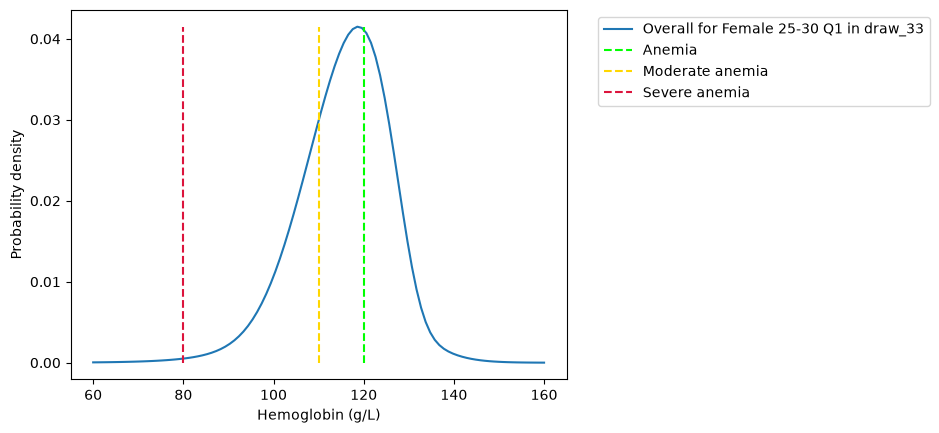

In [83]:
plot_example_distributions({"Overall": hemoglobin_distributions_by_age_sex_quintile})

In [84]:
# Assumption: non-iron-responsive anemias have same distribution of hemoglobin
# as iron-responsive anemias
non_iron_responsive_hemoglobin_distributions = truncate_distributions(
    hemoglobin_distributions_by_age_sex_quintile,
    truncate_max=hgb_info.hgb_upper_mild,
)

In [85]:
# Use even more wiggle room, as the issues in the previous check are "magnified"!
test_pdfs_cdfs_consistency(
    non_iron_responsive_hemoglobin_distributions,
    mean_tolerance=0.01,
    max_tolerance=0.10,
)

count    3.069000e+03
mean     4.388165e-04
std      9.809885e-04
min     -1.985531e-07
25%      8.531390e-06
50%      1.034250e-04
75%      4.426276e-04
max      1.069995e-02
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_58    -1.985531e-07
                            1                draw_161   -1.639340e-07
                            2                draw_34    -1.341246e-07
                            1                draw_50    -1.328275e-07
                            5                draw_186   -1.090820e-07
                                                             ...     
Female  70.000000  75.0     1                draw_134    9.220341e-03
                            2                draw_141    9.320297e-03
        55.000000  60.0     3                draw_115    9.849714e-03
        10.000000  15.0     1                draw_27     1.036091e-02
                            3                draw_134    1.069995e-02
Length: 3069, dtype: float64

count    3069.000000
mean        0.000387
std         0.000983
min        -0.000181
25%        -0.000012
50%         0.000049
75%         0.000378
max         0.010666
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Female  0.076712   0.5      3                draw_208   -0.000181
Male    0.500000   1.0      4                draw_49    -0.000180
        0.076712   0.5      2                draw_34    -0.000179
                            1                draw_50    -0.000179
        0.500000   1.0      5                draw_8     -0.000173
                                                           ...   
Female  70.000000  75.0     1                draw_134    0.009189
                            2                draw_141    0.009291
        55.000000  60.0     3                draw_115    0.009824
        10.000000  15.0     1                draw_27     0.010327
                            3                draw_134    0.010666
Length: 3069, dtype: float64

count    3069.000000
mean       -0.002091
std         0.002608
min        -0.015224
25%        -0.003942
50%        -0.001773
75%        -0.000082
max         0.008527
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.0       15.0     3                draw_131   -0.015224
Female  10.0       15.0     4                draw_139   -0.013255
Male    10.0       15.0     4                draw_238   -0.012624
Female  75.0       80.0     4                draw_139   -0.011245
        95.0       125.0    5                draw_31    -0.010897
                                                           ...   
        55.0       60.0     3                draw_115    0.007195
        10.0       15.0     1                draw_27     0.008117
Male    70.0       75.0     2                draw_115    0.008230
Female  10.0       15.0     3                draw_134    0.008450
Male    75.0       80.0     3                draw_115    0.008527
Length: 3069, dtype: float64

count    3069.000000
mean       -0.005935
std         0.005627
min        -0.090212
25%        -0.007946
50%        -0.004881
75%        -0.002985
max         0.008450
dtype: float64


sex     age_start  age_end    wealth_quintile  draw    
Male    0.0        0.019178   4                draw_91    -0.090212
                                               draw_29    -0.079884
                                               draw_104   -0.075773
                                               draw_240   -0.068947
                              1                draw_3     -0.068231
                                                             ...   
Female  70.0       75.000000  2                draw_141    0.006559
Male    10.0       15.000000  1                draw_115    0.006738
Female  55.0       60.000000  3                draw_115    0.007195
        10.0       15.000000  1                draw_27     0.008117
                              3                draw_134    0.008450
Length: 3069, dtype: float64

count    3069.000000
mean       -0.005935
std         0.005627
min        -0.090212
25%        -0.007946
50%        -0.004881
75%        -0.002985
max         0.008450
dtype: float64


sex     age_start  age_end    wealth_quintile  draw    
Male    0.0        0.019178   4                draw_91    -0.090212
                                               draw_29    -0.079884
                                               draw_104   -0.075773
                                               draw_240   -0.068947
                              1                draw_3     -0.068231
                                                             ...   
Female  70.0       75.000000  2                draw_141    0.006559
Male    10.0       15.000000  1                draw_115    0.006738
Female  55.0       60.000000  3                draw_115    0.007195
        10.0       15.000000  1                draw_27     0.008117
                              3                draw_134    0.008450
Length: 3069, dtype: float64

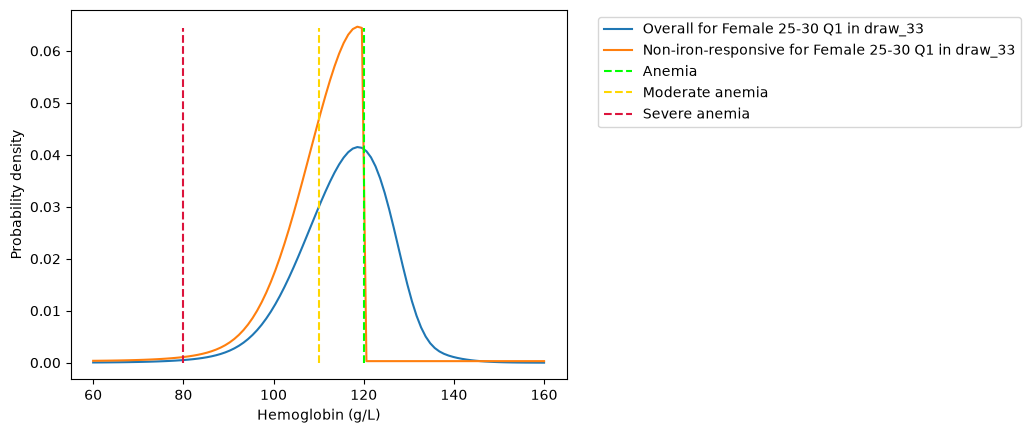

In [86]:
plot_example_distributions(
    {
        "Overall": hemoglobin_distributions_by_age_sex_quintile,
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
    }
)

In [87]:
gbd_hemoglobin_distributions = distributions_from_mean_sd(
    gbd_hgb_mean, gbd_hgb_sd.loc[gbd_hgb_mean.index]
)

In [88]:
gbd_anemia_prevalence = gbd_hemoglobin_distributions.cdfs(
    thresholds.hgb_upper_mild.reindex(gbd_hgb_mean.index)
)
gbd_anemia_prevalence

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.449908
                               draw_1      0.693807
                               draw_2      0.749046
                               draw_3      0.523885
                               draw_4      0.754363
                                             ...   
Male    95.0       125.000000  draw_245    0.327523
                               draw_246    0.241448
                               draw_247    0.352789
                               draw_248    0.356521
                               draw_249    0.591732
Length: 12500, dtype: float64

In [89]:
non_iron_responsive_anemia_proportion = (
    non_iron_responsive_prevalence / gbd_anemia_prevalence
)
non_iron_responsive_anemia_proportion

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.086434
                               draw_1      0.076575
                               draw_2      0.051342
                               draw_3      0.079170
                               draw_4      0.064509
                                             ...   
Male    95.0       125.000000  draw_245    0.193973
                               draw_246    0.159445
                               draw_247    0.139488
                               draw_248    0.137518
                               draw_249    0.056944
Length: 12500, dtype: float64

In [90]:
non_iron_responsive_anemia_proportion

sex     age_start  age_end     draw    
Female  0.0        0.019178    draw_0      0.086434
                               draw_1      0.076575
                               draw_2      0.051342
                               draw_3      0.079170
                               draw_4      0.064509
                                             ...   
Male    95.0       125.000000  draw_245    0.193973
                               draw_246    0.159445
                               draw_247    0.139488
                               draw_248    0.137518
                               draw_249    0.056944
Length: 12500, dtype: float64

In [91]:
hemoglobin_distributions_by_age_sex_quintile.cdfs(hgb_info.hgb_upper_mild)

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      0.499654
                                                draw_1      0.785570
                                                draw_2      0.790637
                                                draw_3      0.618865
                                                draw_4      0.798924
                                                              ...   
Male    95.0       125.000000  5                draw_245    0.274256
                                                draw_246    0.197843
                                                draw_247    0.294805
                                                draw_248    0.302856
                                                draw_249    0.526296
Length: 62500, dtype: float64

In [92]:
non_iron_responsive_anemia_prevalence_by_age_sex_quintile = (
    (
        non_iron_responsive_anemia_proportion
        * hemoglobin_distributions_by_age_sex_quintile.cdfs(hgb_info.hgb_upper_mild)
    )
    .reorder_levels(hgb_info.index.names)
    .reindex(hgb_info.index)
)
non_iron_responsive_anemia_prevalence_by_age_sex_quintile

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    1                draw_0      0.043187
                                                draw_1      0.060155
                                                draw_2      0.040593
                                                draw_3      0.048996
                                                draw_4      0.051538
                                                              ...   
Male    95.0       125.000000  5                draw_245    0.053198
                                                draw_246    0.031545
                                                draw_247    0.041122
                                                draw_248    0.041648
                                                draw_249    0.029970
Length: 62500, dtype: float64

In [93]:
iron_responsive_distributions = delete_from_mixture_distributions(
    hemoglobin_distributions_by_age_sex_quintile,
    non_iron_responsive_hemoglobin_distributions,
    non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
)

In [94]:
test_pdfs_cdfs_consistency(
    iron_responsive_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.624543e-04
std      3.233094e-04
min     -1.433748e-07
25%      3.539705e-06
50%      3.840200e-05
75%      1.788695e-04
max      3.183478e-03
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_58    -1.433748e-07
                                             draw_34    -1.135815e-07
                            1                draw_161   -1.132770e-07
                                             draw_50    -9.793028e-08
                            5                draw_186   -7.330033e-08
                                                             ...     
                                             draw_75     2.821898e-03
Female  70.000000  75.0     1                draw_134    2.838931e-03
        10.000000  15.0     1                draw_27     3.028304e-03
        55.000000  60.0     3                draw_115    3.146499e-03
        10.000000  15.0     3                draw_134    3.183478e-03
Length: 3069, dtype: float64

count    3069.000000
mean        0.000137
std         0.000325
min        -0.000152
25%        -0.000006
50%         0.000016
75%         0.000149
max         0.003173
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_34    -0.000152
        0.500000   1.0      4                draw_49    -0.000151
                            5                draw_8     -0.000141
        0.076712   0.5      5                draw_84    -0.000138
Female  0.076712   0.5      3                draw_208   -0.000135
                                                           ...   
Male    0.076712   0.5      5                draw_75     0.002810
Female  70.000000  75.0     1                draw_134    0.002829
        10.000000  15.0     1                draw_27     0.003018
        55.000000  60.0     3                draw_115    0.003138
        10.000000  15.0     3                draw_134    0.003173
Length: 3069, dtype: float64

count    3.069000e+03
mean     3.549940e-04
std      4.136963e-04
min     -1.014826e-03
25%      8.111040e-07
50%      3.430009e-04
75%      5.310755e-04
max      3.440306e-03
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    95.000000  125.000000  2                draw_229   -0.001015
                               1                draw_160   -0.000650
Female  0.019178   0.076712    4                draw_84    -0.000590
Male    75.000000  80.000000   5                draw_139   -0.000453
        95.000000  125.000000  1                draw_218   -0.000448
                                                              ...   
Female  70.000000  75.000000   2                draw_141    0.002997
                               1                draw_134    0.003019
        10.000000  15.000000   1                draw_27     0.003123
                               3                draw_134    0.003237
        55.000000  60.000000   3                draw_115    0.003440
Length: 3069, dtype: float64

count    3069.000000
mean        0.000592
std         0.000435
min         0.000048
25%         0.000355
50%         0.000515
75%         0.000687
max         0.007917
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Female  0.019178   0.076712    1                draw_76     0.000048
        0.000000   0.019178    1                draw_229    0.000053
        0.019178   0.076712    1                draw_165    0.000054
Male    0.019178   0.076712    4                draw_194    0.000066
Female  0.500000   1.000000    4                draw_238    0.000069
                                                              ...   
        10.000000  15.000000   3                draw_134    0.003266
        55.000000  60.000000   3                draw_115    0.003471
Male    0.000000   0.019178    4                draw_91     0.003562
        95.000000  125.000000  1                draw_218    0.003835
        0.000000   0.019178    1                draw_3      0.007917
Length: 3069, dtype: float64

count    3069.000000
mean        0.000564
std         0.000431
min         0.000030
25%         0.000342
50%         0.000480
75%         0.000643
max         0.008455
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Female  0.000000   0.019178    1                draw_229    0.000030
        0.019178   0.076712    1                draw_76     0.000048
                                                draw_165    0.000054
Male    0.019178   0.076712    4                draw_194    0.000066
Female  0.500000   1.000000    4                draw_238    0.000068
                                                              ...   
Male    0.000000   0.019178    4                draw_29     0.003396
Female  55.000000  60.000000   3                draw_115    0.003453
Male    95.000000  125.000000  1                draw_218    0.003835
        0.000000   0.019178    4                draw_91     0.004324
                               1                draw_3      0.008455
Length: 3069, dtype: float64

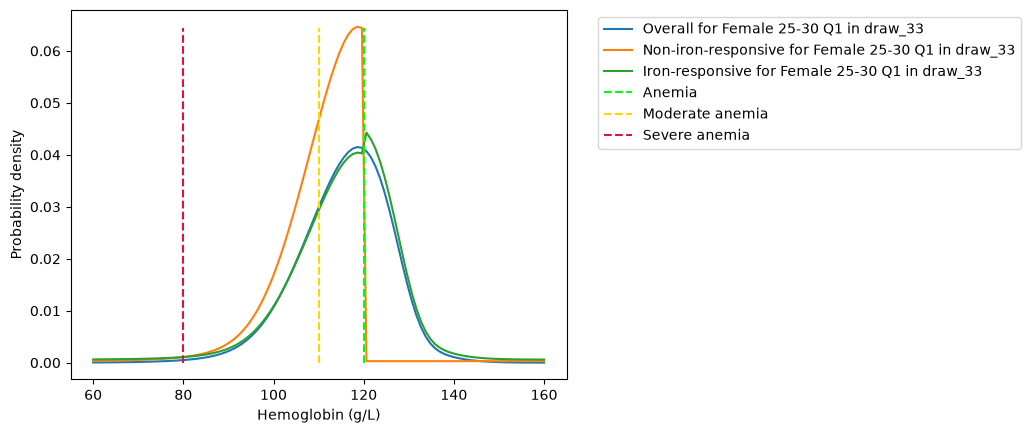

In [95]:
plot_example_distributions(
    {
        "Overall": hemoglobin_distributions_by_age_sex_quintile,
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
        "Iron-responsive": iron_responsive_distributions,
    }
)

In [96]:
# NOTE: this decomposition, like what we do for wealth quintile above,
# is not exact -- we pretend that these two distributions would mix
# to the overall iron-responsive distribution, but they wouldn't.
# Here, we delete baseline coverage baked into the GBD 2021 distribution
# to get the without-fortification distribution.
# Also note that this and the next shift both assume that the hemoglobin effect among
# the responsive is a fixed value without individual-level variation.
iron_responsive_without_fortification_distributions = shift_distributions(
    iron_responsive_distributions,
    -effective_coverage_2021 * hemoglobin_effect_among_responsive.align(hgb_info)[0],
)

In [97]:
test_pdfs_cdfs_consistency(
    iron_responsive_without_fortification_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.624543e-04
std      3.233094e-04
min     -1.433748e-07
25%      3.539705e-06
50%      3.840200e-05
75%      1.788695e-04
max      3.183478e-03
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_58    -1.433748e-07
                                             draw_34    -1.135815e-07
                            1                draw_161   -1.132770e-07
                                             draw_50    -9.793028e-08
                            5                draw_186   -7.330033e-08
                                                             ...     
                                             draw_75     2.821898e-03
Female  70.000000  75.0     1                draw_134    2.838931e-03
        10.000000  15.0     1                draw_27     3.028304e-03
        55.000000  60.0     3                draw_115    3.146499e-03
        10.000000  15.0     3                draw_134    3.183478e-03
Length: 3069, dtype: float64

count    3069.000000
mean        0.000137
std         0.000325
min        -0.000152
25%        -0.000006
50%         0.000016
75%         0.000149
max         0.003173
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_34    -0.000152
        0.500000   1.0      4                draw_49    -0.000151
                            5                draw_8     -0.000141
        0.076712   0.5      5                draw_84    -0.000138
Female  0.076712   0.5      3                draw_208   -0.000135
                                                           ...   
Male    0.076712   0.5      5                draw_75     0.002810
Female  70.000000  75.0     1                draw_134    0.002829
        10.000000  15.0     1                draw_27     0.003018
        55.000000  60.0     3                draw_115    0.003138
        10.000000  15.0     3                draw_134    0.003173
Length: 3069, dtype: float64

count    3.069000e+03
mean     3.549940e-04
std      4.136963e-04
min     -1.014826e-03
25%      8.111040e-07
50%      3.430009e-04
75%      5.310755e-04
max      3.440306e-03
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    95.000000  125.000000  2                draw_229   -0.001015
                               1                draw_160   -0.000650
Female  0.019178   0.076712    4                draw_84    -0.000590
Male    75.000000  80.000000   5                draw_139   -0.000453
        95.000000  125.000000  1                draw_218   -0.000448
                                                              ...   
Female  70.000000  75.000000   2                draw_141    0.002997
                               1                draw_134    0.003019
        10.000000  15.000000   1                draw_27     0.003123
                               3                draw_134    0.003237
        55.000000  60.000000   3                draw_115    0.003440
Length: 3069, dtype: float64

count    3069.000000
mean        0.000592
std         0.000435
min         0.000048
25%         0.000355
50%         0.000515
75%         0.000687
max         0.007917
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Female  0.019178   0.076712    1                draw_76     0.000048
        0.000000   0.019178    1                draw_229    0.000053
        0.019178   0.076712    1                draw_165    0.000054
Male    0.019178   0.076712    4                draw_194    0.000066
Female  0.500000   1.000000    4                draw_238    0.000069
                                                              ...   
        10.000000  15.000000   3                draw_134    0.003266
        55.000000  60.000000   3                draw_115    0.003471
Male    0.000000   0.019178    4                draw_91     0.003562
        95.000000  125.000000  1                draw_218    0.003835
        0.000000   0.019178    1                draw_3      0.007917
Length: 3069, dtype: float64

count    3069.000000
mean        0.000564
std         0.000431
min         0.000030
25%         0.000342
50%         0.000480
75%         0.000643
max         0.008455
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Female  0.000000   0.019178    1                draw_229    0.000030
        0.019178   0.076712    1                draw_76     0.000048
                                                draw_165    0.000054
Male    0.019178   0.076712    4                draw_194    0.000066
Female  0.500000   1.000000    4                draw_238    0.000068
                                                              ...   
Male    0.000000   0.019178    4                draw_29     0.003396
Female  55.000000  60.000000   3                draw_115    0.003453
Male    95.000000  125.000000  1                draw_218    0.003835
        0.000000   0.019178    4                draw_91     0.004324
                               1                draw_3      0.008455
Length: 3069, dtype: float64

In [98]:
iron_responsive_with_fortification_distributions = shift_distributions(
    iron_responsive_without_fortification_distributions,
    hemoglobin_effect_among_responsive.align(hgb_info)[0],
)

In [99]:
test_pdfs_cdfs_consistency(
    iron_responsive_with_fortification_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.638357e-04
std      3.252664e-04
min     -5.936830e-08
25%      3.659849e-06
50%      3.900375e-05
75%      1.809068e-04
max      3.201481e-03
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_34    -5.936830e-08
                                             draw_58    -5.398360e-08
                            5                draw_186   -3.766267e-08
Female  95.000000  125.0    3                draw_6     -1.567351e-08
        60.000000  65.0     4                draw_118   -1.456676e-08
                                                             ...     
Male    0.076712   0.5      5                draw_75     2.837587e-03
Female  70.000000  75.0     1                draw_134    2.854942e-03
        10.000000  15.0     1                draw_27     3.042820e-03
        55.000000  60.0     3                draw_115    3.161002e-03
        10.000000  15.0     3                draw_134    3.201481e-03
Length: 3069, dtype: float64

count    3069.000000
mean        0.000143
std         0.000326
min        -0.000126
25%        -0.000002
50%         0.000020
75%         0.000154
max         0.003191
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.500000   1.0      4                draw_49    -0.000126
                            5                draw_8     -0.000117
        0.076712   0.5      5                draw_84    -0.000114
Female  0.076712   0.5      1                draw_231   -0.000105
        1.000000   2.0      1                draw_230   -0.000102
                                                           ...   
Male    0.076712   0.5      5                draw_75     0.002824
Female  70.000000  75.0     1                draw_134    0.002845
        10.000000  15.0     1                draw_27     0.003033
        55.000000  60.0     3                draw_115    0.003152
        10.000000  15.0     3                draw_134    0.003191
Length: 3069, dtype: float64

count    3069.000000
mean       -0.000352
std         0.000633
min        -0.003998
25%        -0.000656
50%        -0.000204
75%        -0.000010
max         0.002984
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.000000  15.0     1                draw_217   -0.003998
                            3                draw_131   -0.003635
Female  60.000000  65.0     1                draw_31    -0.003513
        80.000000  85.0     4                draw_214   -0.003361
        60.000000  65.0     3                draw_124   -0.003321
                                                           ...   
Male    70.000000  75.0     2                draw_115    0.002413
        0.076712   0.5      5                draw_75     0.002414
Female  10.000000  15.0     1                draw_27     0.002645
Male    75.000000  80.0     3                draw_115    0.002783
Female  10.000000  15.0     3                draw_134    0.002984
Length: 3069, dtype: float64

count    3069.000000
mean       -0.000609
std         0.000649
min        -0.006168
25%        -0.000873
50%        -0.000572
75%        -0.000309
max         0.003012
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    95.000000  125.0    1                draw_218   -0.006168
                                             draw_160   -0.004705
        10.000000  15.0     3                draw_131   -0.004330
                            1                draw_217   -0.003886
Female  60.000000  65.0     1                draw_31    -0.003613
                                                           ...   
        55.000000  60.0     3                draw_115    0.002374
        70.000000  75.0     1                draw_134    0.002420
Male    0.076712   0.5      5                draw_75     0.002443
Female  10.000000  15.0     1                draw_27     0.002674
                            3                draw_134    0.003012
Length: 3069, dtype: float64

count    3069.000000
mean       -0.000647
std         0.000636
min        -0.006168
25%        -0.000895
50%        -0.000608
75%        -0.000341
max         0.003002
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    95.000000  125.0    1                draw_218   -0.006168
                                             draw_160   -0.004705
        10.000000  15.0     3                draw_131   -0.004330
                            1                draw_217   -0.003894
Female  60.000000  65.0     1                draw_31    -0.003613
                                                           ...   
        55.000000  60.0     3                draw_115    0.002361
        70.000000  75.0     1                draw_134    0.002412
Male    0.076712   0.5      5                draw_75     0.002416
Female  10.000000  15.0     1                draw_27     0.002662
                            3                draw_134    0.003002
Length: 3069, dtype: float64

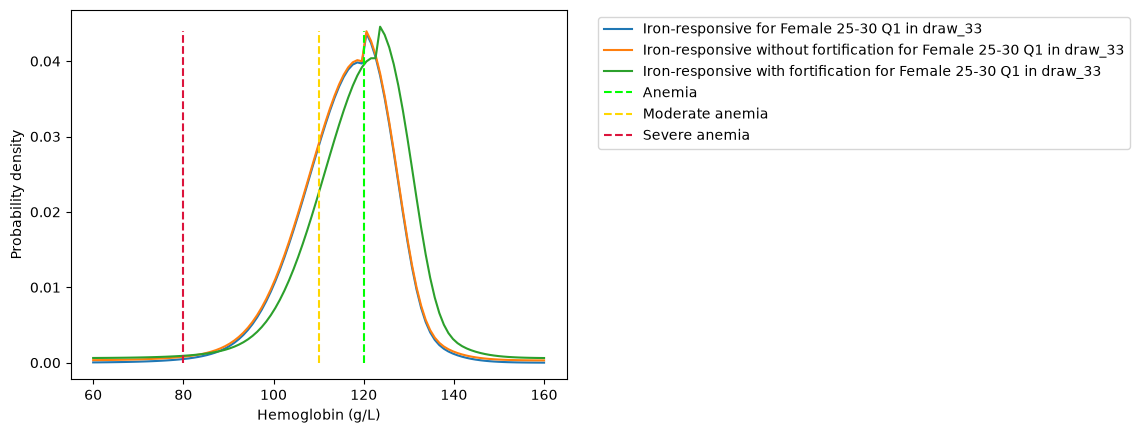

In [100]:
plot_example_distributions(
    {
        "Iron-responsive": iron_responsive_distributions,
        "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
        "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
    }
)

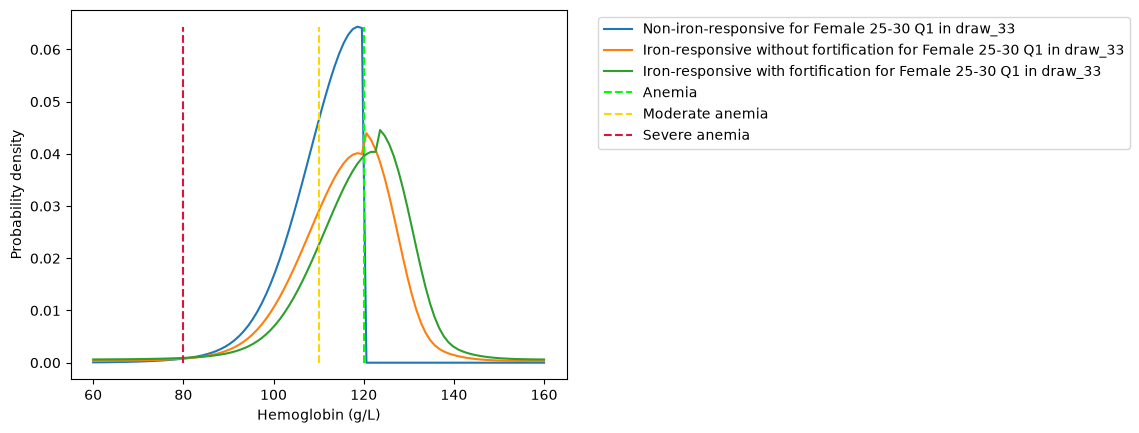

In [101]:
plot_example_distributions(
    {
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
        "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
        "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
    }
)

In [102]:
zero_fort_scenario_distributions = mix_distributions(
    [
        (
            non_iron_responsive_hemoglobin_distributions,
            non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
        ),
        (
            iron_responsive_without_fortification_distributions,
            1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
        ),
    ]
)

In [103]:
test_pdfs_cdfs_consistency(
    zero_fort_scenario_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.798405e-04
std      3.677012e-04
min     -1.470494e-07
25%      3.881262e-06
50%      4.282242e-05
75%      1.955918e-04
max      3.820251e-03
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_58    -1.470494e-07
                            1                draw_161   -1.157366e-07
                            2                draw_34    -1.142703e-07
                            1                draw_50    -9.966205e-08
                            5                draw_186   -7.537461e-08
                                                             ...     
Female  10.000000  15.0     1                draw_27     3.337264e-03
                            3                draw_134    3.373092e-03
Male    75.000000  80.0     3                draw_115    3.381954e-03
Female  70.000000  75.0     2                draw_141    3.440901e-03
        55.000000  60.0     3                draw_115    3.820251e-03
Length: 3069, dtype: float64

count    3069.000000
mean        0.000153
std         0.000370
min        -0.000153
25%        -0.000006
50%         0.000018
75%         0.000165
max         0.003810
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_34    -0.000153
        0.500000   1.0      4                draw_49    -0.000152
                            5                draw_8     -0.000142
        0.076712   0.5      5                draw_84    -0.000141
Female  0.076712   0.5      3                draw_208   -0.000137
                                                           ...   
        10.000000  15.0     1                draw_27     0.003326
                            3                draw_134    0.003362
Male    75.000000  80.0     3                draw_115    0.003372
Female  70.000000  75.0     2                draw_141    0.003430
        55.000000  60.0     3                draw_115    0.003810
Length: 3069, dtype: float64

count    3069.000000
mean        0.000201
std         0.000379
min        -0.001113
25%        -0.000002
50%         0.000124
75%         0.000254
max         0.003818
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    95.000000  125.000000  2                draw_229   -0.001113
                               1                draw_160   -0.000760
                                                draw_218   -0.000591
Female  0.019178   0.076712    4                draw_84    -0.000591
Male    75.000000  80.000000   5                draw_139   -0.000495
                                                              ...   
Female  10.000000  15.000000   1                draw_27     0.003333
                               3                draw_134    0.003369
Male    75.000000  80.000000   3                draw_115    0.003375
Female  70.000000  75.000000   2                draw_141    0.003437
        55.000000  60.000000   3                draw_115    0.003818
Length: 3069, dtype: float64

count    3069.000000
mean        0.000208
std         0.000372
min        -0.000728
25%         0.000016
50%         0.000105
75%         0.000228
max         0.003846
dtype: float64


sex     age_start  age_end    wealth_quintile  draw    
Male    0.0        0.019178   4                draw_91    -0.000728
                                               draw_29    -0.000693
                                               draw_104   -0.000640
                                               draw_240   -0.000549
                              1                draw_3     -0.000479
                                                             ...   
Female  10.0       15.000000  1                draw_27     0.003362
Male    75.0       80.000000  3                draw_115    0.003396
Female  10.0       15.000000  3                draw_134    0.003397
        70.0       75.000000  2                draw_141    0.003465
        55.0       60.000000  3                draw_115    0.003846
Length: 3069, dtype: float64

count    3.069000e+03
mean     1.818141e-04
std      3.692087e-04
min     -3.067324e-12
25%      4.458418e-06
50%      4.521655e-05
75%      1.972569e-04
max      3.829184e-03
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    95.000000  125.000000  2                draw_229   -3.067324e-12
        0.000000   0.019178    2                draw_214   -4.587442e-13
                               1                draw_7     -1.711964e-13
        0.019178   0.076712    1                draw_218   -1.492140e-13
Female  0.000000   0.019178    4                draw_36    -1.060263e-13
                                                                ...     
        10.000000  15.000000   1                draw_27     3.345798e-03
                               3                draw_134    3.382208e-03
Male    75.000000  80.000000   3                draw_115    3.397302e-03
Female  70.000000  75.000000   2                draw_141    3.449912e-03
        55.000000  60.000000   3                draw_115    3.829184e-03
Length: 3069, dtype: float64

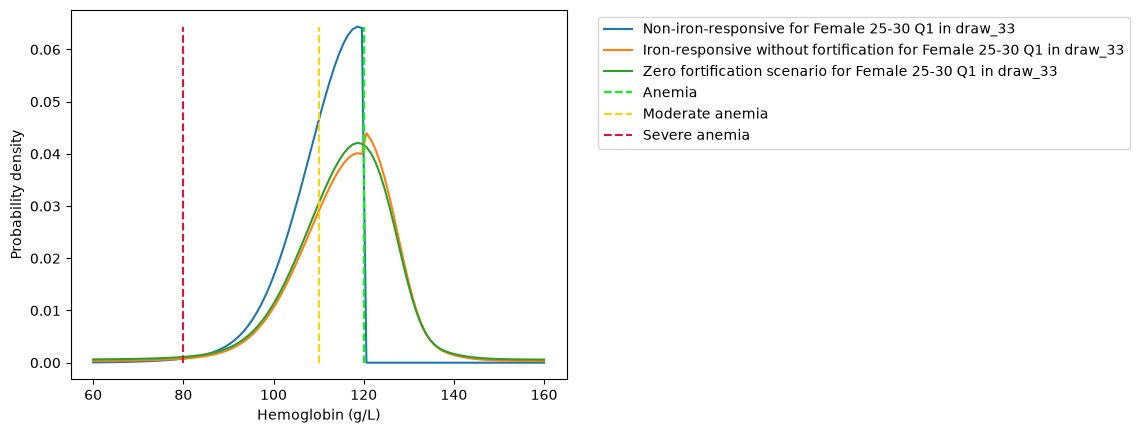

In [104]:
plot_example_distributions(
    {
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
        "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
        "Zero fortification scenario": zero_fort_scenario_distributions,
    }
)

In [105]:
baseline_scenario_distributions = mix_distributions(
    [
        (
            non_iron_responsive_hemoglobin_distributions,
            non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
        ),
        (
            iron_responsive_without_fortification_distributions,
            (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile)
            * (1 - effective_coverage_baseline),
        ),
        (
            iron_responsive_with_fortification_distributions,
            (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile)
            * effective_coverage_baseline,
        ),
    ]
)

In [106]:
test_pdfs_cdfs_consistency(
    baseline_scenario_distributions,
    mean_tolerance=0.005,
    max_tolerance=0.05,
)

count    3.069000e+03
mean     1.801971e-04
std      3.682215e-04
min     -1.243830e-07
25%      3.913844e-06
50%      4.294802e-05
75%      1.959711e-04
max      3.824311e-03
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_58    -1.243830e-07
                                             draw_34    -1.000368e-07
                            1                draw_161   -8.690111e-08
                            5                draw_186   -7.065630e-08
                            1                draw_50    -6.186812e-08
                                                             ...     
Female  10.000000  15.0     1                draw_27     3.342194e-03
                            3                draw_134    3.378838e-03
Male    75.000000  80.0     3                draw_115    3.385264e-03
Female  70.000000  75.0     2                draw_141    3.444129e-03
        55.000000  60.0     3                draw_115    3.824311e-03
Length: 3069, dtype: float64

count    3069.000000
mean        0.000154
std         0.000370
min        -0.000146
25%        -0.000005
50%         0.000019
75%         0.000167
max         0.003814
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.500000   1.0      4                draw_49    -0.000146
                            5                draw_8     -0.000138
        0.076712   0.5      5                draw_84    -0.000137
                            2                draw_34    -0.000134
Female  0.076712   0.5      3                draw_208   -0.000127
                                                           ...   
        10.000000  15.0     1                draw_27     0.003331
                            3                draw_134    0.003368
Male    75.000000  80.0     3                draw_115    0.003376
Female  70.000000  75.0     2                draw_141    0.003433
        55.000000  60.0     3                draw_115    0.003814
Length: 3069, dtype: float64

count    3069.000000
mean        0.000020
std         0.000410
min        -0.001598
25%        -0.000143
50%        -0.000032
75%         0.000088
max         0.003511
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.0       15.0     1                draw_217   -0.001598
Female  60.0       65.0     1                draw_31    -0.001280
        85.0       90.0     2                draw_36    -0.001229
        60.0       65.0     2                draw_56    -0.001223
        80.0       85.0     1                draw_218   -0.001208
                                                           ...   
        70.0       75.0     1                draw_134    0.003018
        10.0       15.0     1                draw_27     0.003171
                            3                draw_134    0.003288
Male    75.0       80.0     3                draw_115    0.003378
Female  55.0       60.0     3                draw_115    0.003511
Length: 3069, dtype: float64

count    3069.000000
mean       -0.000101
std         0.000460
min        -0.003062
25%        -0.000312
50%        -0.000149
75%         0.000025
max         0.003538
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    95.0       125.000000  1                draw_218   -0.003062
        0.0        0.019178    1                draw_3     -0.002487
        95.0       125.000000  1                draw_160   -0.002453
                               2                draw_229   -0.001855
        0.0        0.019178    4                draw_91    -0.001764
                                                              ...   
Female  70.0       75.000000   1                draw_134    0.003045
Male    75.0       80.000000   3                draw_115    0.003098
Female  10.0       15.000000   1                draw_27     0.003200
                               3                draw_134    0.003316
        55.0       60.000000   3                draw_115    0.003538
Length: 3069, dtype: float64

count    3069.000000
mean       -0.000129
std         0.000457
min        -0.003062
25%        -0.000345
50%        -0.000173
75%        -0.000014
max         0.003523
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    95.0       125.000000  1                draw_218   -0.003062
        0.0        0.019178    1                draw_3     -0.002666
        95.0       125.000000  1                draw_160   -0.002453
                               2                draw_229   -0.001855
        10.0       15.000000   3                draw_131   -0.001615
                                                              ...   
Female  70.0       75.000000   1                draw_134    0.003034
Male    75.0       80.000000   3                draw_115    0.003101
Female  10.0       15.000000   1                draw_27     0.003185
                               3                draw_134    0.003303
        55.0       60.000000   3                draw_115    0.003523
Length: 3069, dtype: float64

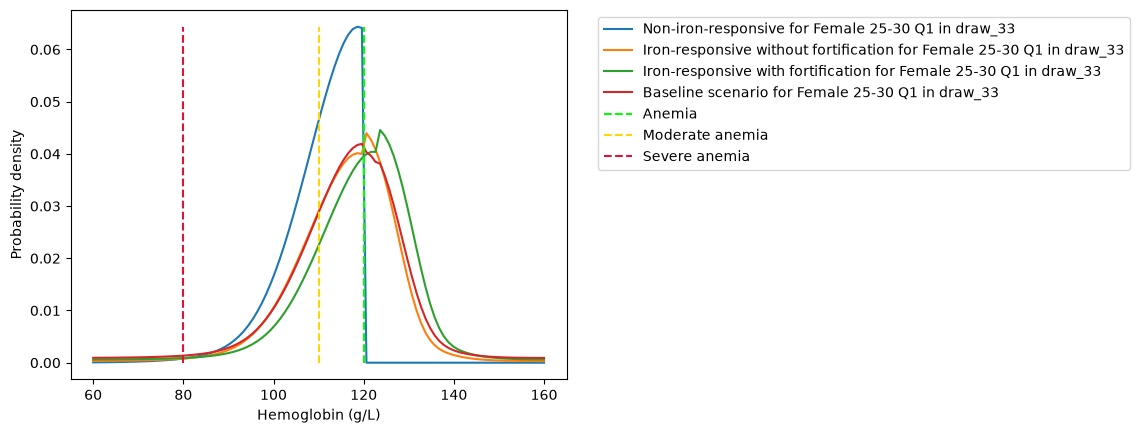

In [107]:
plot_example_distributions(
    {
        "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
        "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
        "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
        "Baseline scenario": baseline_scenario_distributions,
    }
)

In [108]:
intervention_scenario_distributions = {}

for intervention_scenario in intervention_scenarios:
    effective_coverage_for_scenario = (
        effective_coverage_intervention[
            effective_coverage_intervention.index.get_level_values("scenario")
            == intervention_scenario
        ]
        .droplevel("scenario")
        .reindex(hgb_info.index)
    )
    intervention_scenario_distributions[intervention_scenario] = mix_distributions(
        [
            (
                non_iron_responsive_hemoglobin_distributions,
                non_iron_responsive_anemia_prevalence_by_age_sex_quintile,
            ),
            (
                iron_responsive_without_fortification_distributions,
                (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile)
                * (1 - effective_coverage_for_scenario),
            ),
            (
                iron_responsive_with_fortification_distributions,
                (1 - non_iron_responsive_anemia_prevalence_by_age_sex_quintile)
                * effective_coverage_for_scenario,
            ),
        ]
    )

In [109]:
for _, dists in intervention_scenario_distributions.items():
    test_pdfs_cdfs_consistency(
        dists,
        mean_tolerance=0.005,
        max_tolerance=0.05,
    )

count    3.069000e+03
mean     1.805281e-04
std      3.686681e-04
min     -1.061683e-07
25%      3.937128e-06
50%      4.308158e-05
75%      1.963186e-04
max      3.827767e-03
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.076712   0.5      2                draw_58    -1.061683e-07
                                             draw_34    -8.859876e-08
                            1                draw_161   -6.367994e-08
                            5                draw_186   -6.068763e-08
                            1                draw_50    -3.143270e-08
                                                             ...     
Female  10.000000  15.0     1                draw_27     3.345273e-03
                            3                draw_134    3.383514e-03
Male    75.000000  80.0     3                draw_115    3.388092e-03
Female  70.000000  75.0     2                draw_141    3.446280e-03
        55.000000  60.0     3                draw_115    3.827767e-03
Length: 3069, dtype: float64

count    3069.000000
mean        0.000156
std         0.000370
min        -0.000140
25%        -0.000004
50%         0.000020
75%         0.000168
max         0.003817
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    0.500000   1.0      4                draw_49    -0.000140
                            5                draw_8     -0.000132
        0.076712   0.5      5                draw_84    -0.000131
                            2                draw_34    -0.000119
Female  0.076712   0.5      3                draw_208   -0.000117
                                                           ...   
        10.000000  15.0     1                draw_27     0.003334
                            3                draw_134    0.003373
Male    75.000000  80.0     3                draw_115    0.003379
Female  70.000000  75.0     2                draw_141    0.003435
        55.000000  60.0     3                draw_115    0.003817
Length: 3069, dtype: float64

count    3069.000000
mean       -0.000153
std         0.000508
min        -0.002549
25%        -0.000388
50%        -0.000091
75%         0.000010
max         0.003381
dtype: float64


sex     age_start  age_end  wealth_quintile  draw    
Male    10.0       15.0     1                draw_217   -0.002549
Female  60.0       65.0     1                draw_31    -0.002211
                            3                draw_124   -0.002134
        85.0       90.0     2                draw_36    -0.002134
Male    10.0       15.0     3                draw_131   -0.002124
                                                           ...   
        70.0       75.0     2                draw_115    0.002951
Female  10.0       15.0     1                draw_27     0.003069
                            3                draw_134    0.003222
        55.0       60.0     3                draw_115    0.003250
Male    75.0       80.0     3                draw_115    0.003381
Length: 3069, dtype: float64

count    3069.000000
mean       -0.000391
std         0.000570
min        -0.004865
25%        -0.000647
50%        -0.000405
75%        -0.000160
max         0.003277
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    95.0       125.000000  1                draw_218   -0.004865
        0.0        0.019178    1                draw_3     -0.004105
        95.0       125.000000  1                draw_160   -0.003897
                               2                draw_229   -0.003089
        10.0       15.000000   3                draw_131   -0.002947
                                                              ...   
        75.0       80.000000   3                draw_115    0.002844
Female  70.0       75.000000   1                draw_134    0.002920
        10.0       15.000000   1                draw_27     0.003098
                               3                draw_134    0.003250
        55.0       60.000000   3                draw_115    0.003277
Length: 3069, dtype: float64

count    3069.000000
mean       -0.000422
std         0.000569
min        -0.004865
25%        -0.000681
50%        -0.000431
75%        -0.000189
max         0.003263
dtype: float64


sex     age_start  age_end     wealth_quintile  draw    
Male    95.0       125.000000  1                draw_218   -0.004865
        0.0        0.019178    1                draw_3     -0.004813
        95.0       125.000000  1                draw_160   -0.003897
                               2                draw_229   -0.003089
        10.0       15.000000   3                draw_131   -0.002947
                                                              ...   
        75.0       80.000000   3                draw_115    0.002848
Female  70.0       75.000000   1                draw_134    0.002910
        10.0       15.000000   1                draw_27     0.003084
                               3                draw_134    0.003238
        55.0       60.000000   3                draw_115    0.003263
Length: 3069, dtype: float64

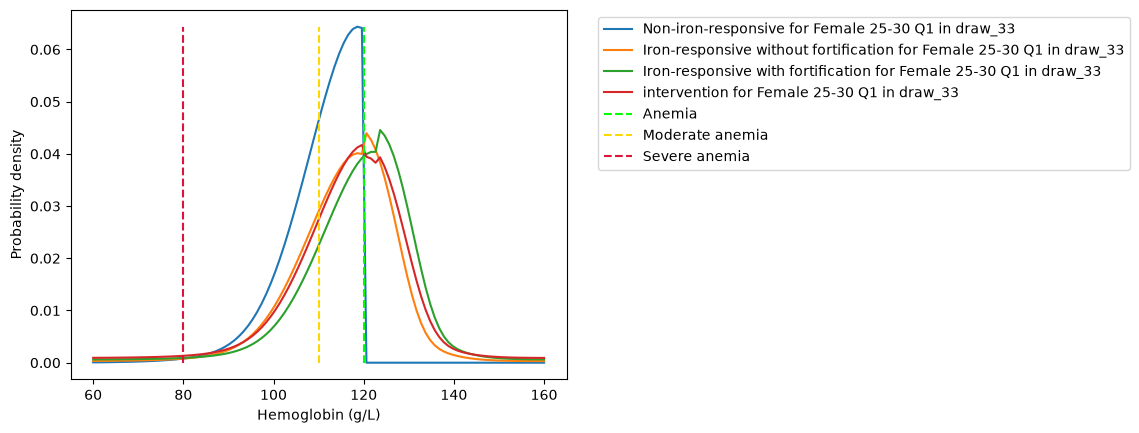

In [110]:
for intervention_scenario in intervention_scenarios:
    plot_example_distributions(
        {
            "Non-iron-responsive": non_iron_responsive_hemoglobin_distributions,
            "Iron-responsive without fortification": iron_responsive_without_fortification_distributions,
            "Iron-responsive with fortification": iron_responsive_with_fortification_distributions,
            intervention_scenario: intervention_scenario_distributions[
                intervention_scenario
            ],
        }
    )
    plt.show()

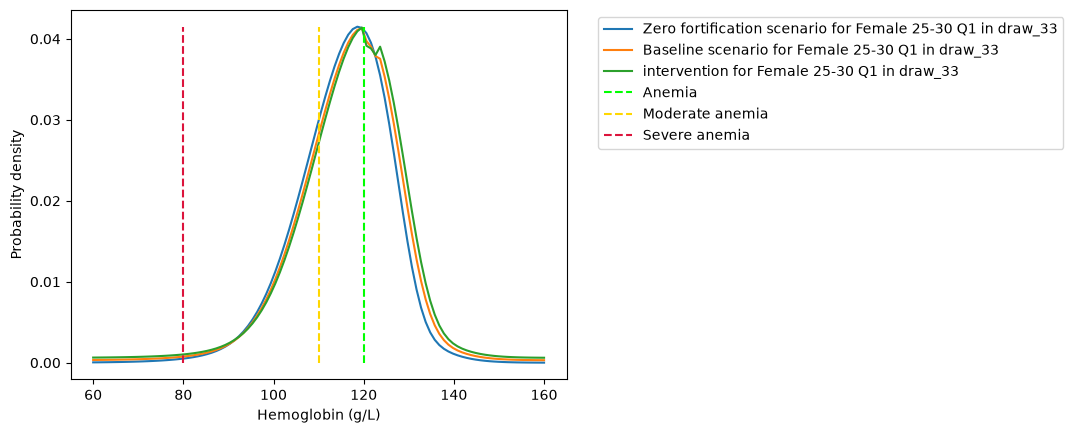

In [111]:
plot_example_distributions(
    {
        "Zero fortification scenario": zero_fort_scenario_distributions,
        "Baseline scenario": baseline_scenario_distributions,
        **intervention_scenario_distributions,
    }
)

In [112]:
def anemia_by_severity_from_distributions(distributions: Distributions):
    result = pd.DataFrame(index=distributions.data_index)
    assert result.index.equals(hgb_info.index)

    result["severe"] = distributions.cdfs(
        hgb_info.hgb_upper_severe.copy()
    ) - distributions.cdfs(hgb_info.hgb_lower_severe.copy())
    result["moderate"] = (
        distributions.cdfs(hgb_info.hgb_upper_moderate.copy()) - result["severe"]
    )
    result["mild"] = (
        distributions.cdfs(hgb_info.hgb_upper_mild.copy())
        - result["moderate"]
        - result["severe"]
    )
    result["anemic"] = result["mild"] + result["moderate"] + result["severe"]

    assert (result >= 0).all().all()
    assert (result <= 1).all().all()
    return result

In [113]:
zero_fort_scenario_anemia_by_severity = anemia_by_severity_from_distributions(
    zero_fort_scenario_distributions
)
zero_fort_scenario_anemia_by_severity

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.015646  0.251685   
                                            draw_1    0.001640  0.294487   
                                            draw_2    0.055920  0.489417   
                                            draw_3    0.001394  0.196246   
                                            draw_4    0.042619  0.491660   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_245  0.001029  0.025859   
                                            draw_246  0.001219  0.021285   
                                            draw_247  0.000754  0.023894   
                                            draw_248  0.001278  0.031246   
                                            draw_249  0.000933  0.048164   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.232323  0.499654  
                                            draw_1    0.489443  0.785570  
                                            draw_2    0.245301  0.790637  
                                            draw_3    0.421225  0.618865  
                                            draw_4    0.264645  0.798924  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_245  0.247368  0.274256  
                                            draw_246  0.175340  0.197843  
                                            draw_247  0.270157  0.294805  
                                            draw_248  0.270332  0.302856  
                                            draw_249  0.477199  0.526296  

[62500 rows x 4 columns]

In [114]:
baseline_scenario_anemia_by_severity = anemia_by_severity_from_distributions(
    baseline_scenario_distributions
)
baseline_scenario_anemia_by_severity

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.014933  0.241952   
                                            draw_1    0.001517  0.273969   
                                            draw_2    0.053039  0.477598   
                                            draw_3    0.001294  0.181689   
                                            draw_4    0.040310  0.478407   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_245  0.000997  0.024902   
                                            draw_246  0.001182  0.020544   
                                            draw_247  0.000727  0.022905   
                                            draw_248  0.001236  0.030015   
                                            draw_249  0.000893  0.045741   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.228352  0.485238  
                                            draw_1    0.482495  0.757981  
                                            draw_2    0.246793  0.777430  
                                            draw_3    0.407848  0.590832  
                                            draw_4    0.266290  0.785007  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_245  0.240171  0.266069  
                                            draw_246  0.170022  0.191748  
                                            draw_247  0.261411  0.285043  
                                            draw_248  0.262429  0.293681  
                                            draw_249  0.463440  0.510074  

[62500 rows x 4 columns]

In [115]:
intervention_scenarios_anemia_by_severity = {}

for scenario, distributions in intervention_scenario_distributions.items():
    anemia_by_severity = anemia_by_severity_from_distributions(distributions)
    print(scenario)
    display(anemia_by_severity)
    intervention_scenarios_anemia_by_severity[scenario] = anemia_by_severity

intervention


severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.014367  0.234206   
                                            draw_1    0.001419  0.257641   
                                            draw_2    0.050747  0.468192   
                                            draw_3    0.001214  0.170105   
                                            draw_4    0.038472  0.467860   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_245  0.000914  0.022462   
                                            draw_246  0.001090  0.018655   
                                            draw_247  0.000659  0.020385   
                                            draw_248  0.001129  0.026879   
                                            draw_249  0.000793  0.039568   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.225192  0.473765  
                                            draw_1    0.476965  0.736025  
                                            draw_2    0.247981  0.766920  
                                            draw_3    0.397203  0.568522  
                                            draw_4    0.267600  0.773931  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_245  0.221831  0.245207  
                                            draw_246  0.156470  0.176215  
                                            draw_247  0.239123  0.260167  
                                            draw_248  0.242293  0.270300  
                                            draw_249  0.428376  0.468737  

[62500 rows x 4 columns]

In [116]:
# Transform the intervention scenarios back from a dictionary to the scenario being a level
# in the MultiIndex, which is easier to work with now that we are out of function/distribution space.
intervention_scenarios_anemia_by_severity = pd.concat(
    [
        anemia_by_severity.assign(scenario=scenario).set_index("scenario", append=True)
        for scenario, anemia_by_severity in intervention_scenarios_anemia_by_severity.items()
    ]
)
intervention_scenarios_anemia_by_severity

severe  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.014367   
                                            draw_1   intervention  0.001419   
                                            draw_2   intervention  0.050747   
                                            draw_3   intervention  0.001214   
                                            draw_4   intervention  0.038472   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention  0.000914   
                                            draw_246 intervention  0.001090   
                                            draw_247 intervention  0.000659   
                                            draw_248 intervention  0.001129   
                                            draw_249 intervention  0.000793   

                                                                   moderate  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.234206   
                                            draw_1   intervention  0.257641   
                                            draw_2   intervention  0.468192   
                                            draw_3   intervention  0.170105   
                                            draw_4   intervention  0.467860   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention  0.022462   
                                            draw_246 intervention  0.018655   
                                            draw_247 intervention  0.020385   
                                            draw_248 intervention  0.026879   
                                            draw_249 intervention  0.039568   

                                                                       mild  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.225192   
                                            draw_1   intervention  0.476965   
                                            draw_2   intervention  0.247981   
                                            draw_3   intervention  0.397203   
                                            draw_4   intervention  0.267600   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention  0.221831   
                                            draw_246 intervention  0.156470   
                                            draw_247 intervention  0.239123   
                                            draw_248 intervention  0.242293   
                                            draw_249 intervention  0.428376   

                                                                     anemic  
sex    age_start age_end    wealth_quintile draw     scenario                
Female 0.0       0.019178   1               draw_0   intervention  0.473765  
                                            draw_1   intervention  0.736025  
                                            draw_2   intervention  0.766920  
                                            draw_3   intervention  0.568522  
                                            draw_4   intervention  0.773931  
...                                                                     ...  
Male   95.0      125.000000 5               draw_245 intervention  0.245207  
                                            draw_246 intervention  0.176215  
                                            draw_247 intervention  0.260167  
                                            draw_248 intervention  0.270300  
                                            draw_

In [117]:
zero_fort_scenario_anemia_by_severity - baseline_scenario_anemia_by_severity

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   1               draw_0    0.000712  0.009734   
                                            draw_1    0.000123  0.020517   
                                            draw_2    0.002881  0.011819   
                                            draw_3    0.000100  0.014557   
                                            draw_4    0.002309  0.013253   
...                                                        ...       ...   
Male   95.0      125.000000 5               draw_245  0.000032  0.000957   
                                            draw_246  0.000036  0.000741   
                                            draw_247  0.000027  0.000989   
                                            draw_248  0.000042  0.001231   
                                            draw_249  0.000039  0.002423   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0    0.003971  0.014416  
                                            draw_1    0.006948  0.027589  
                                            draw_2   -0.001493  0.013207  
                                            draw_3    0.013377  0.028033  
                                            draw_4   -0.001646  0.013917  
...                                                        ...       ...  
Male   95.0      125.000000 5               draw_245  0.007197  0.008187  
                                            draw_246  0.005318  0.006095  
                                            draw_247  0.008746  0.009762  
                                            draw_248  0.007902  0.009175  
                                            draw_249  0.013760  0.016222  

[62500 rows x 4 columns]

In [118]:
baseline_scenario_anemia_by_severity - intervention_scenarios_anemia_by_severity

severe  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.000567   
                                            draw_1   intervention  0.000098   
                                            draw_2   intervention  0.002292   
                                            draw_3   intervention  0.000080   
                                            draw_4   intervention  0.001838   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention  0.000082   
                                            draw_246 intervention  0.000092   
                                            draw_247 intervention  0.000068   
                                            draw_248 intervention  0.000107   
                                            draw_249 intervention  0.000100   

                                                                   moderate  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.007746   
                                            draw_1   intervention  0.016328   
                                            draw_2   intervention  0.009406   
                                            draw_3   intervention  0.011584   
                                            draw_4   intervention  0.010547   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention  0.002439   
                                            draw_246 intervention  0.001889   
                                            draw_247 intervention  0.002520   
                                            draw_248 intervention  0.003137   
                                            draw_249 intervention  0.006173   

                                                                       mild  \
sex    age_start age_end    wealth_quintile draw     scenario                 
Female 0.0       0.019178   1               draw_0   intervention  0.003160   
                                            draw_1   intervention  0.005530   
                                            draw_2   intervention -0.001188   
                                            draw_3   intervention  0.010645   
                                            draw_4   intervention -0.001310   
...                                                                     ...   
Male   95.0      125.000000 5               draw_245 intervention  0.018340   
                                            draw_246 intervention  0.013552   
                                            draw_247 intervention  0.022288   
                                            draw_248 intervention  0.020137   
                                            draw_249 intervention  0.035063   

                                                                     anemic  
sex    age_start age_end    wealth_quintile draw     scenario                
Female 0.0       0.019178   1               draw_0   intervention  0.011473  
                                            draw_1   intervention  0.021956  
                                            draw_2   intervention  0.010511  
                                            draw_3   intervention  0.022310  
                                            draw_4   intervention  0.011076  
...                                                                     ...  
Male   95.0      125.000000 5               draw_245 intervention  0.020862  
                                            draw_246 intervention  0.015533  
                                            draw_247 intervention  0.024876  
                                            draw_248 intervention  0.023381  
                                            draw_

<Axes: >

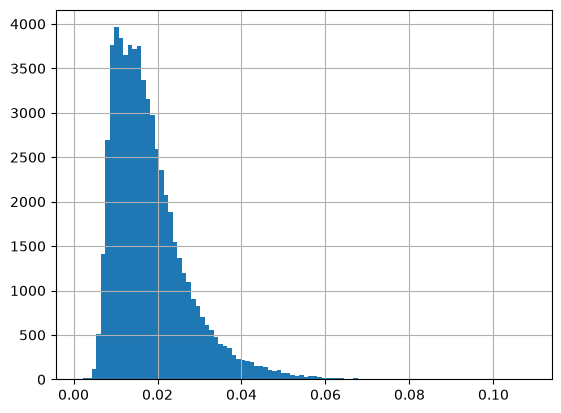

In [119]:
# We can see that in very rare cases, likely due to numerical instability, we get a negative impact
(
    baseline_scenario_anemia_by_severity - intervention_scenarios_anemia_by_severity
).anemic.hist(bins=100)

In [120]:
def anemia_by_severity_to_yld_rates(anemia_by_severity):
    disability_weights = pd.read_hdf(
        "/mnt/team/simulation_science/costeffectiveness/auxiliary_data/GBD_2021/02_processed_data/disability_weight/sequela/all/all.hdf"
    )
    disability_weights = (
        disability_weights[
            disability_weights.healthstate.isin(
                ["anemia_mild", "anemia_mod", "anemia_sev"]
            )
        ]
        .set_index("healthstate")
        .filter(like="draw_")
    )
    disability_weights.columns.name = "draw"
    disability_weights = (
        disability_weights.stack().rename("disability_weight").reset_index()
    )
    display(disability_weights)

    orig_index = anemia_by_severity.index
    anemia_by_severity = (
        anemia_by_severity.reset_index()
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mild"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "mild_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_mod"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "moderate_dw"}),
            validate="m:1",
        )
        .merge(
            disability_weights[disability_weights.healthstate == "anemia_sev"][
                ["draw", "disability_weight"]
            ].rename(columns={"disability_weight": "severe_dw"}),
            validate="m:1",
        )
    )

    anemia_by_severity["mild_yld_rate"] = (
        anemia_by_severity.mild * anemia_by_severity.mild_dw
    )
    anemia_by_severity["moderate_yld_rate"] = (
        anemia_by_severity.moderate * anemia_by_severity.moderate_dw
    )
    anemia_by_severity["severe_yld_rate"] = (
        anemia_by_severity.severe * anemia_by_severity.severe_dw
    )
    anemia_by_severity["anemic_yld_rate"] = (
        anemia_by_severity["mild_yld_rate"]
        + anemia_by_severity["moderate_yld_rate"]
        + anemia_by_severity["severe_yld_rate"]
    )

    return anemia_by_severity.set_index(orig_index.names).filter(like="yld_rate")

In [121]:
zero_fort_scenario_anemia_yld_rates = anemia_by_severity_to_yld_rates(
    zero_fort_scenario_anemia_by_severity
)
zero_fort_scenario_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   1               draw_0         0.000562   
                            2               draw_0         0.000534   
                            3               draw_0         0.000520   
                            4               draw_0         0.000496   
                            5               draw_0         0.000485   
...                                                             ...   
Male   95.0      125.000000 1               draw_249       0.003061   
                            2               draw_249       0.002877   
                            3               draw_249       0.002787   
                            4               draw_249       0.002680   
                            5               draw_249       0.002540   

                                                      moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0             0.014925   
                            2               draw_0             0.013256   
                            3               draw_0             0.013338   
                            4               draw_0             0.012020   
                            5               draw_0             0.010547   
...                                                                 ...   
Male   95.0      125.000000 1               draw_249           0.006602   
                            2               draw_249           0.005711   
                            3               draw_249           0.005592   
                            4               draw_249           0.004743   
                            5               draw_249           0.003555   

                                                      severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                        
Female 0.0       0.019178   1               draw_0           0.003113   
                            2               draw_0           0.002714   
                            3               draw_0           0.002945   
                            4               draw_0           0.002608   
                            5               draw_0           0.002046   
...                                                               ...   
Male   95.0      125.000000 1               draw_249         0.000337   
                            2               draw_249         0.000308   
                            3               draw_249         0.000321   
                            4               draw_249         0.000263   
                            5               draw_249         0.000176   

                                                      anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0           0.018600  
                            2               draw_0           0.016503  
                            3               draw_0           0.016803  
                            4               draw_0           0.015124  
                            5               draw_0           0.013077  
...                                                               ...  
Male   95.0      125.000000 1               draw_249         0.010000  
                            2               draw_249         0.008895  
                            3               draw_249         0.008700  
                            4               draw_249         0.007686  
                            5               draw_249         0.006271  

[62500 rows x 4 columns]

In [122]:
baseline_scenario_anemia_yld_rates = anemia_by_severity_to_yld_rates(
    baseline_scenario_anemia_by_severity
)
baseline_scenario_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   1               draw_0         0.000553   
                            2               draw_0         0.000523   
                            3               draw_0         0.000511   
                            4               draw_0         0.000487   
                            5               draw_0         0.000478   
...                                                             ...   
Male   95.0      125.000000 1               draw_249       0.002893   
                            2               draw_249       0.002710   
                            3               draw_249       0.002638   
                            4               draw_249       0.002542   
                            5               draw_249       0.002467   

                                                      moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   1               draw_0             0.014348   
                            2               draw_0             0.012733   
                            3               draw_0             0.012862   
                            4               draw_0             0.011590   
                            5               draw_0             0.010304   
...                                                                 ...   
Male   95.0      125.000000 1               draw_249           0.005775   
                            2               draw_249           0.005021   
                            3               draw_249           0.004984   
                            4               draw_249           0.004276   
                            5               draw_249           0.003376   

                                                      severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                        
Female 0.0       0.019178   1               draw_0           0.002971   
                            2               draw_0           0.002596   
                            3               draw_0           0.002828   
                            4               draw_0           0.002509   
                            5               draw_0           0.001999   
...                                                               ...   
Male   95.0      125.000000 1               draw_249         0.000300   
                            2               draw_249         0.000276   
                            3               draw_249         0.000291   
                            4               draw_249         0.000241   
                            5               draw_249         0.000169   

                                                      anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   1               draw_0           0.017871  
                            2               draw_0           0.015853  
                            3               draw_0           0.016200  
                            4               draw_0           0.014586  
                            5               draw_0           0.012781  
...                                                               ...  
Male   95.0      125.000000 1               draw_249         0.008968  
                            2               draw_249         0.008008  
                            3               draw_249         0.007914  
                            4               draw_249         0.007059  
                            5               draw_249         0.006012  

[62500 rows x 4 columns]

In [123]:
intervention_anemia_yld_rates = anemia_by_severity_to_yld_rates(
    intervention_scenarios_anemia_by_severity
)
intervention_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                      
Female 0.0       0.019178   1               draw_0   intervention       0.000545   
                            2               draw_0   intervention       0.000515   
                            3               draw_0   intervention       0.000502   
                            4               draw_0   intervention       0.000477   
                            5               draw_0   intervention       0.000466   
...                                                                          ...   
Male   95.0      125.000000 1               draw_249 intervention       0.002794   
                            2               draw_249 intervention       0.002599   
                            3               draw_249 intervention       0.002511   
                            4               draw_249 intervention       0.002401   
                            5               draw_249 intervention       0.002280   

                                                                   moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                          
Female 0.0       0.019178   1               draw_0   intervention           0.013889   
                            2               draw_0   intervention           0.012300   
                            3               draw_0   intervention           0.012405   
                            4               draw_0   intervention           0.011137   
                            5               draw_0   intervention           0.009807   
...                                                                              ...   
Male   95.0      125.000000 1               draw_249 intervention           0.005288   
                            2               draw_249 intervention           0.004563   
                            3               draw_249 intervention           0.004464   
                            4               draw_249 intervention           0.003803   
                            5               draw_249 intervention           0.002921   

                                                                   severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw     scenario                        
Female 0.0       0.019178   1               draw_0   intervention         0.002858   
                            2               draw_0   intervention         0.002498   
                            3               draw_0   intervention         0.002715   
                            4               draw_0   intervention         0.002405   
                            5               draw_0   intervention         0.001904   
...                                                                            ...   
Male   95.0      125.000000 1               draw_249 intervention         0.000279   
                            2               draw_249 intervention         0.000255   
                            3               draw_249 intervention         0.000266   
                            4               draw_249 intervention         0.000219   
                            5               draw_249 intervention         0.000150   

                                                                   anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw     scenario                       
Female 0.0       0.019178   1               draw_0   intervention         0.017292  
                            2               draw_0   intervention         0.015313  
                            3               draw_0   intervention         0.015622  
                            4               draw_0   intervention         0.014020  
                            5               draw_0   intervention         0.012176  
...                                                                            ...  
Male   95.0      125.000000 1 

In [124]:
(baseline_scenario_anemia_yld_rates - intervention_anemia_yld_rates).sort_values(
    "anemic_yld_rate"
)

mild_yld_rate  \
sex    age_start age_end   wealth_quintile draw     scenario                      
Male   0.0       0.019178  5               draw_98  intervention   9.341102e-06   
                           4               draw_98  intervention   1.086963e-05   
                           5               draw_38  intervention   1.672725e-05   
                           2               draw_98  intervention   1.611961e-05   
                           5               draw_103 intervention   1.836645e-05   
...                                                                         ...   
Female 10.0      15.000000 2               draw_131 intervention   2.006278e-04   
Male   0.5       1.000000  5               draw_89  intervention   5.031146e-07   
Female 10.0      15.000000 3               draw_131 intervention   2.285785e-04   
       5.0       10.000000 5               draw_180 intervention   5.678951e-05   
       10.0      15.000000 1               draw_131 intervention   8.847892e-05   

                                                                  moderate_yld_rate  \
sex    age_start age_end   wealth_quintile draw     scenario                          
Male   0.0       0.019178  5               draw_98  intervention       1.869519e-06   
                           4               draw_98  intervention       2.194111e-06   
                           5               draw_38  intervention       1.831972e-06   
                           2               draw_98  intervention       3.010980e-06   
                           5               draw_103 intervention       9.066537e-07   
...                                                                             ...   
Female 10.0      15.000000 2               draw_131 intervention       2.605904e-03   
Male   0.5       1.000000  5               draw_89  intervention       2.693139e-03   
Female 10.0      15.000000 3               draw_131 intervention       2.725061e-03   
       5.0       10.000000 5               draw_180 intervention       2.760802e-03   
       10.0      15.000000 1               draw_131 intervention       3.143299e-03   

                                                                  severe_yld_rate  \
sex    age_start age_end   wealth_quintile draw     scenario                        
Male   0.0       0.019178  5               draw_98  intervention     1.437344e-10   
                           4               draw_98  intervention     2.017392e-10   
                           5               draw_38  intervention     6.779643e-13   
                           2               draw_98  intervention     2.388794e-10   
                           5               draw_103 intervention     7.897198e-14   
...                                                                           ...   
Female 10.0      15.000000 2               draw_131 intervention     4.302541e-07   
Male   0.5       1.000000  5               draw_89  intervention     1.231429e-04   
Female 10.0      15.000000 3               draw_131 intervention     5.378168e-07   
       5.0       10.000000 5               draw_180 intervention     1.888637e-04   
       10.0      15.000000 1               draw_131 intervention     5.685337e-07   

                                                                  anemic_yld_rate  
sex    age_start age_end   wealth_quintile draw     scenario                       
Male   0.0       0.019178  5               draw_98  intervention         0.000011  
                           4               draw_98  intervention         0.000013  
                           5               draw_38  intervention         0.000019  
                           2               draw_98  intervention         0.000019  
                           5               draw_103 intervention         0.000019  
...                                                                           ...  
Female 10.0      15.000000 2               draw_131 intervention         0.0

<Axes: >

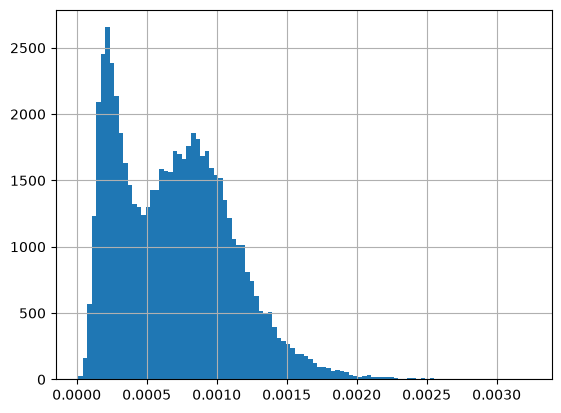

In [125]:
(
    baseline_scenario_anemia_yld_rates - intervention_anemia_yld_rates
).anemic_yld_rate.hist(bins=100)

In [126]:
zero_fort_scenario_ylds = (
    zero_fort_scenario_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
zero_fort_scenario_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  1186.490411
                               2                   901.389895
                               3                   798.971870
                               4                   664.417092
                               5                   465.048259
                                                     ...     
Male    95.0       125.000000  1                    90.225283
                               2                    83.771432
                               3                    84.886891
                               4                    78.676876
                               5                    78.208847
Length: 250, dtype: float64

In [127]:
baseline_scenario_ylds = (
    baseline_scenario_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
baseline_scenario_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  1126.688253
                               2                   856.119269
                               3                   762.177353
                               4                   634.508058
                               5                   452.107091
                                                     ...     
Male    95.0       125.000000  1                    81.737361
                               2                    76.176114
                               3                    77.930396
                               4                    72.860814
                               5                    75.258990
Length: 250, dtype: float64

In [128]:
intervention_scenarios_ylds = (
    intervention_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1)
    * non_pregnant_pop
)
intervention_scenarios_ylds

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    1079.096187
                               2                intervention     818.540190
                               3                intervention     726.909663
                               4                intervention     603.029150
                               5                intervention     425.725612
                                                                   ...     
Male    95.0       125.000000  1                intervention      76.740774
                               2                intervention      71.124606
                               3                intervention      71.983957
                               4                intervention      66.963850
                               5                intervention      67.741937
Length: 250, dtype: float64

In [129]:
(
    baseline_scenario_ylds.loc[("Female", 25, 30, 1)].mean()
    - intervention_scenarios_ylds.loc[("Female", 25, 30, 1)].mean()
)

8127.514229411958

In [130]:
(
    baseline_scenario_ylds.groupby(["wealth_quintile"]).sum()
    - intervention_scenarios_ylds.groupby(["scenario", "wealth_quintile"]).sum()
)

scenario      wealth_quintile
intervention  1                  181125.033204
              2                  177037.346838
              3                  194213.993715
              4                  189830.363315
              5                  211320.974977
dtype: float64

In [131]:
ylds = pd.concat(
    [
        zero_fort_scenario_ylds.rename("value").reset_index().assign(scenario="zero"),
        baseline_scenario_ylds.rename("value")
        .reset_index()
        .assign(scenario="baseline"),
        intervention_scenarios_ylds.rename("value").reset_index(),
    ],
    ignore_index=True,
)
ylds

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,1186.490411,zero
1,Female,0.0,0.019178,2,901.389895,zero
2,Female,0.0,0.019178,3,798.971870,zero
3,Female,0.0,0.019178,4,664.417092,zero
4,Female,0.0,0.019178,5,465.048259,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,76.740774,intervention
746,Male,95.0,125.000000,2,71.124606,intervention
747,Male,95.0,125.000000,3,71.983957,intervention
748,Male,95.0,125.000000,4,66.963850,intervention


In [132]:
results_dir = f"./results/{vehicle.lower()}/{location.lower()}"

In [133]:
path = f"{results_dir}/ylds.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
ylds.to_parquet(path)

In [134]:
zero_fort_anemia_prevalence = (
    zero_fort_scenario_anemia_by_severity["anemic"].unstack("draw").mean(axis=1)
)
zero_fort_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.813534
                               2                  0.763972
                               3                  0.753302
                               4                  0.704209
                               5                  0.662124
                                                    ...   
Male    95.0       125.000000  1                  0.514412
                               2                  0.467551
                               3                  0.451761
                               4                  0.417781
                               5                  0.371171
Length: 250, dtype: float64

In [135]:
baseline_anemia_prevalence = (
    baseline_scenario_anemia_by_severity["anemic"].unstack("draw").mean(axis=1)
)
baseline_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  0.794246
                               2                  0.741780
                               3                  0.732597
                               4                  0.682283
                               5                  0.647948
                                                    ...   
Male    95.0       125.000000  1                  0.476227
                               2                  0.432676
                               3                  0.421001
                               4                  0.391263
                               5                  0.358575
Length: 250, dtype: float64

In [136]:
zero_fort_anemia_cases = zero_fort_anemia_prevalence.mul(non_pregnant_pop, axis=0)
zero_fort_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  39601.769161
                               2                  32639.498130
                               3                  28574.791970
                               4                  25160.080603
                               5                  18957.590376
                                                      ...     
Male    95.0       125.000000  1                   9428.603393
                               2                   8949.032575
                               3                   8931.430187
                               4                   8711.271638
                               5                   9543.290103
Length: 250, dtype: float64

In [137]:
zero_fort_anemia_cases.sum() / non_pregnant_pop.sum()

0.41317126151227385

In [138]:
baseline_anemia_cases = baseline_anemia_prevalence.mul(non_pregnant_pop, axis=0)
baseline_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    1                  38662.857218
                               2                  31691.382960
                               3                  27789.403248
                               4                  24376.714116
                               5                  18551.703793
                                                      ...     
Male    95.0       125.000000  1                   8728.699716
                               2                   8281.517945
                               3                   8323.302388
                               4                   8158.352603
                               5                   9219.424219
Length: 250, dtype: float64

In [139]:
baseline_anemia_cases.sum() / non_pregnant_pop.sum()

0.39616891828806744

In [140]:
baseline_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(
    ["wealth_quintile"]
).sum()

wealth_quintile
1    0.439834
2    0.407758
3    0.399472
4    0.378412
5    0.356966
dtype: float64

In [141]:
intervention_anemia_prevalence = (
    intervention_scenarios_anemia_by_severity["anemic"].unstack("draw").mean(axis=1)
)
intervention_anemia_prevalence

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    0.778896
                               2                intervention    0.723359
                               3                intervention    0.712752
                               4                intervention    0.659206
                               5                intervention    0.619049
                                                                  ...   
Male    95.0       125.000000  1                intervention    0.453748
                               2                intervention    0.409481
                               3                intervention    0.394708
                               4                intervention    0.364377
                               5                intervention    0.326476
Length: 250, dtype: float64

In [142]:
anemia_prevalence = pd.concat(
    [
        zero_fort_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="zero"),
        baseline_anemia_prevalence.rename("value")
        .reset_index()
        .assign(scenario="baseline"),
        intervention_anemia_prevalence.rename("value").reset_index(),
    ],
    ignore_index=True,
)
anemia_prevalence

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,0.813534,zero
1,Female,0.0,0.019178,2,0.763972,zero
2,Female,0.0,0.019178,3,0.753302,zero
3,Female,0.0,0.019178,4,0.704209,zero
4,Female,0.0,0.019178,5,0.662124,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,0.453748,intervention
746,Male,95.0,125.000000,2,0.409481,intervention
747,Male,95.0,125.000000,3,0.394708,intervention
748,Male,95.0,125.000000,4,0.364377,intervention


In [143]:
path = f"{results_dir}/anemia_prevalence.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_prevalence.to_parquet(path)

In [144]:
intervention_anemia_cases = intervention_anemia_prevalence.mul(non_pregnant_pop, axis=0)
intervention_anemia_cases

sex     age_start  age_end     wealth_quintile  scenario    
Female  0.0        0.019178    1                intervention    37915.647404
                               2                intervention    30904.353966
                               3                intervention    27036.605055
                               4                intervention    23552.230064
                               5                intervention    17724.275501
                                                                    ...     
Male    95.0       125.000000  1                intervention     8316.687185
                               2                intervention     7837.566104
                               3                intervention     7803.472372
                               4                intervention     7597.742323
                               5                intervention     8394.124128
Length: 250, dtype: float64

In [145]:
intervention_anemia_cases.sum() / non_pregnant_pop.sum()

0.3801015625206415

In [146]:
intervention_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(
    ["wealth_quintile"]
).sum()

wealth_quintile
1    0.425709
2    0.393329
3    0.383606
4    0.362186
5    0.337374
dtype: float64

In [147]:
(
    baseline_anemia_cases.groupby(["wealth_quintile"]).sum()
    - intervention_anemia_cases.groupby(["wealth_quintile"]).sum()
).map(lambda x: f"{round(x):,.0f}")

wealth_quintile
1    3,950,392
2    4,091,926
3    4,533,818
4    4,661,967
5    5,667,724
dtype: object

In [148]:
anemia_cases = pd.concat(
    [
        zero_fort_anemia_cases.rename("value").reset_index().assign(scenario="zero"),
        baseline_anemia_cases.rename("value").reset_index().assign(scenario="baseline"),
        intervention_anemia_cases.rename("value").reset_index(),
    ],
    ignore_index=True,
)
anemia_cases

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,1,39601.769161,zero
1,Female,0.0,0.019178,2,32639.498130,zero
2,Female,0.0,0.019178,3,28574.791970,zero
3,Female,0.0,0.019178,4,25160.080603,zero
4,Female,0.0,0.019178,5,18957.590376,zero
...,...,...,...,...,...,...
745,Male,95.0,125.000000,1,8316.687185,intervention
746,Male,95.0,125.000000,2,7837.566104,intervention
747,Male,95.0,125.000000,3,7803.472372,intervention
748,Male,95.0,125.000000,4,7597.742323,intervention


In [149]:
path = f"{results_dir}/anemia_cases.parquet"
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_cases.to_parquet(path)